# XP and Trajectory Gem Classification Model

This notebook documents the **XP + weak visual model** for collected experience gems in
`video4_Imelda_100.mp4`. Its unit of analysis is an **XP-jump event**, not every gem visible
on screen. A persistent increase in the XP bar confirms that at least one gem was collected;
the model then estimates the pickup color using:

- XP-bar increase normalized for visible HUD level and Imelda's Growth;
- weak multi-frame gem trajectories near Imelda's health-bar anchor;
- blue, green, and red template detections in Frames A and B;
- disappearance and unmatched-candidate evidence; and
- trajectory count, template score, and timing quality.

The notebook separates three questions that must not be confused:

1. **Pickup confirmation:** did the XP bar increase?
2. **Color classification:** was the pickup most consistent with blue, green, or red?
3. **Quantity estimation:** how many gems contributed to the same XP jump?

The XP jump answers the first question. The classifier addresses the second. The third can
remain unresolved when multiple gems arrive in one frame or when a level-up truncates the
visible XP increase.

Human-coded counts are never used to fit the model or choose its thresholds. They are read
only after prediction for an independent five-second evaluation. Model outputs are written
separately; the official detector files and shared source spreadsheet are never modified.

## Pipeline at a glance

| Step | Operation | Output |
|---|---|---|
| 1 | Load confirmed XP-jump events | One row per persistent XP increase |
| 2 | Select clean visual references | Single-gem, non-saturated blue/green/red examples |
| 3 | Recover level, Imelda Growth, and Crown level | Growth multiplier active before each pickup |
| 4 | Calculate Crown-aware normalized XP | Comparable estimated base XP across levels |
| 5 | Build weak visual features | Counts, colors, scores, disappearance, and trajectory evidence |
| 6 | Run three-fold out-of-fold validation | Every reference predicted by a model that did not train on it |
| 7 | Train on all usable references | Final blue/green classifier plus guarded red rule |
| 8 | Apply the level-up visual rule | Ignore censored XP and require one strong disappearing track |
| 9 | Predict unresolved events | Candidate color or unresolved with a likely color |
| 10 | Aggregate candidates | Event, per-second, and five-second tables |
| 11 | Evaluate against human coding | Independent first-five-minute count metrics |

Blue and green are learned statistically. Red uses an additional guard requiring normalized
XP above the green range plus a sufficiently strong weak red trajectory. This is necessary
because only three visually resolved red references are available.

### Evidence hierarchy

The model gives priority to multi-frame evidence. A gem trajectory that approaches Imelda and
disappears at the pickup boundary is stronger than a single-frame color match. XP magnitude
helps distinguish colors only after correcting for level and Growth. It never overrides
obvious multiplicity, saturation, or conflicting trajectories.

In [ ]:
from pathlib import Path
import importlib.util
import json
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image as NotebookImage, display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedKFold


def find_workspace():
    for candidate in [Path.cwd(), *Path.cwd().parents]:
        if (candidate / "MNL" / "videos" / "video4_Imelda_100.mp4").exists():
            return candidate
    raise FileNotFoundError("Could not locate the UCSB workspace")


def load_model_helpers(path):
    spec = importlib.util.spec_from_file_location("weak_visual_helpers", path)
    if spec is None or spec.loader is None:
        raise RuntimeError(f"Could not load model helpers: {path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[spec.name] = module
    spec.loader.exec_module(module)
    return module


WORKSPACE = find_workspace()
PROJECT = WORKSPACE / "MNL" / "02_blue_gems"
MODEL_DIR = PROJECT / "XP and Trajectory Gem Classification Model"
OUTPUT = MODEL_DIR / "model_outputs"
OUTPUT.mkdir(parents=True, exist_ok=True)
EVENTS_CSV = (
    PROJECT / "results" / "video4_Imelda_100" / "collected_gems_cv_final"
    / "collected_gems_video4_imelda_100_xp_ab_events.csv"
)
HELPER_SCRIPT = PROJECT / "scripts" / "compare_unresolved_color_methods.py"
HUMAN_BLUE_CSV = (
    PROJECT / "data" / "raw"
    / "video4_imelda_100_human_collected_blue_gems_first5min.csv"
)
HUMAN_GEMS_CSV = (
    PROJECT / "data" / "raw"
    / "video4_imelda_100_human_collected_gems_first5min.csv"
)
helpers = load_model_helpers(HELPER_SCRIPT)

assert EVENTS_CSV.exists() and HELPER_SCRIPT.exists()
MODEL_DIR

## Reference data

A visual reference event must satisfy all four conditions:

1. exactly one collected gem;
2. no unresolved gem in the event;
3. the XP bar did not saturate; and
4. color came from a visual trajectory or disappearance rule.

The reference color comes from visible trajectory/disappearance evidence. Percentage-assisted
labels are excluded; otherwise an XP-derived label would be reused as the target of an
XP-based model, creating circular validation. The 1,254 references contain 971 blue, 280
green, and only 3 red events.

These references are **computer-vision pseudo-labels**, not independent human ground truth.
They support model development and internal out-of-fold validation. The separate human-coded
five-second counts are reserved for external evaluation.

,Color,Visual reference events
0,blue,971
1,green,280
2,red,3


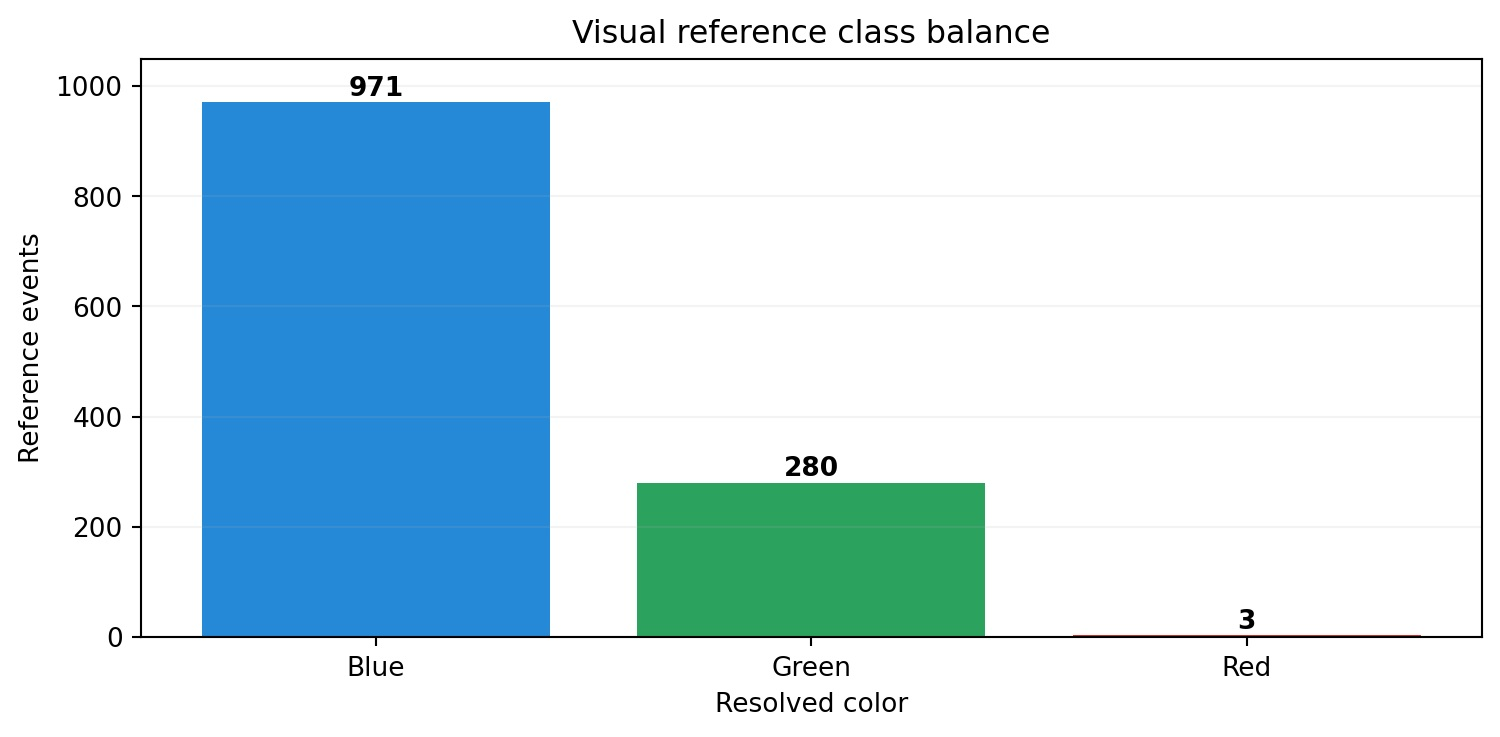

In [2]:
events = helpers.apply_video4_crown_growth(pd.read_csv(EVENTS_CSV))
reference = helpers.visual_reference(events)
unresolved = events.loc[events["unresolved_collected_gems"].gt(0)].copy()

reference_balance = (
    reference["reference_color"]
    .value_counts()
    .reindex(helpers.COLORS, fill_value=0)
    .rename_axis("Color")
    .reset_index(name="Visual reference events")
)
display(reference_balance)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(
    reference_balance["Color"].str.title(),
    reference_balance["Visual reference events"],
    color=[helpers.DISPLAY_COLORS[color] for color in helpers.COLORS],
)
for index, value in enumerate(reference_balance["Visual reference events"]):
    ax.text(index, value + 12, f"{value:,}", ha="center", fontweight="bold")
ax.set(
    title="Visual reference class balance",
    xlabel="Resolved color",
    ylabel="Reference events",
    ylim=(0, 1050),
)
ax.grid(axis="y", alpha=0.15)
fig.tight_layout()
CLASS_BALANCE_PNG = OUTPUT / "visual_reference_class_balance.png"
CLASS_BALANCE_JPG = OUTPUT / "visual_reference_class_balance.jpg"
fig.savefig(CLASS_BALANCE_PNG, dpi=190, bbox_inches="tight")
fig.savefig(CLASS_BALANCE_JPG, dpi=190, bbox_inches="tight", pil_kwargs={"quality": 94})
plt.close(fig)
display(NotebookImage(filename=str(CLASS_BALANCE_JPG), width=850))

assert reference_balance.set_index("Color")["Visual reference events"].to_dict() == {
    "blue": 971, "green": 280, "red": 3,
}
assert len(unresolved) == 849

## Crown-aware level-normalized XP

Let `A` and `B` be the filled XP-bar endpoints before and at the persistent jump, and let
`W` be the complete fillable bar width:

$$
P = 100\left(\frac{B-A}{W}\right).
$$

Video 4 begins with a +15% permanent Growth PowerUp. Imelda adds +10 percentage points at
levels 5, 10, and 15. Crown adds +8 percentage points per upgrade, up to +40%. The Crown
upgrade times were audited from the visible `Growth` value on the level-up screens; they are
not inferred from the model's gem predictions.

The complete bar represents the XP required to leave visible level $L$:

$$
R(L)=
\begin{cases}
5+10(L-1), & 1\le L\le20,\ L\ne20 \\
795, & L=20 \\
195+13(L-20), & 21\le L\le40,\ L\ne40 \\
2855, & L=40 \\
455+16(L-40), & L\ge41.
\end{cases}
$$

The exceptional requirements at levels 20 and 40 are paired with a temporary +100
percentage-point Growth adjustment. Total Growth before an event is:

$$
G_{total}=15\%+G_{Imelda}+8\%\times L_{Crown}+G_{spike}.
$$

Using $G=1+G_{total}/100$ and the detector's 0.994 pixel-calibration correction $C$:

$$
X_{raw} = \frac{P}{100}\frac{R(L)}{G},
\qquad
X_{normalized} = \frac{X_{raw}}{C}.
$$

At level 10 before Crown is acquired, $R(10)=95$ and $G=1.35$. A `2%` XP-bar jump gives:

$$
X_{raw}=0.02\times\frac{95}{1.35}=1.41\ \text{base XP}.
$$

The normalized value remains a feature, not a standalone label. Several blue gems can produce
the same XP total as one green gem, and a saturated level-up jump is right-censored.

### Audited Crown schedule

The level-up statistics panel shows the active Growth percentage. Its sequence
`35% -> 43% -> 51% -> 61% -> 69% -> 169% -> 77% -> 85%` verifies the five +8% Crown steps,
Imelda's level-15 increase, and the temporary level-20 adjustment. Crown level changes only
after the selected level-up menu closes, so `crown_level_before` cannot use a future upgrade.

,Crown level,Activation frame,Video time,Crown Growth (%)
0,0,0,0:00.000,0
1,1,5530,3:04.333,8
2,2,6026,3:20.867,16
3,3,7350,4:05.000,24
4,4,10449,5:48.300,32
5,5,14759,8:11.967,40


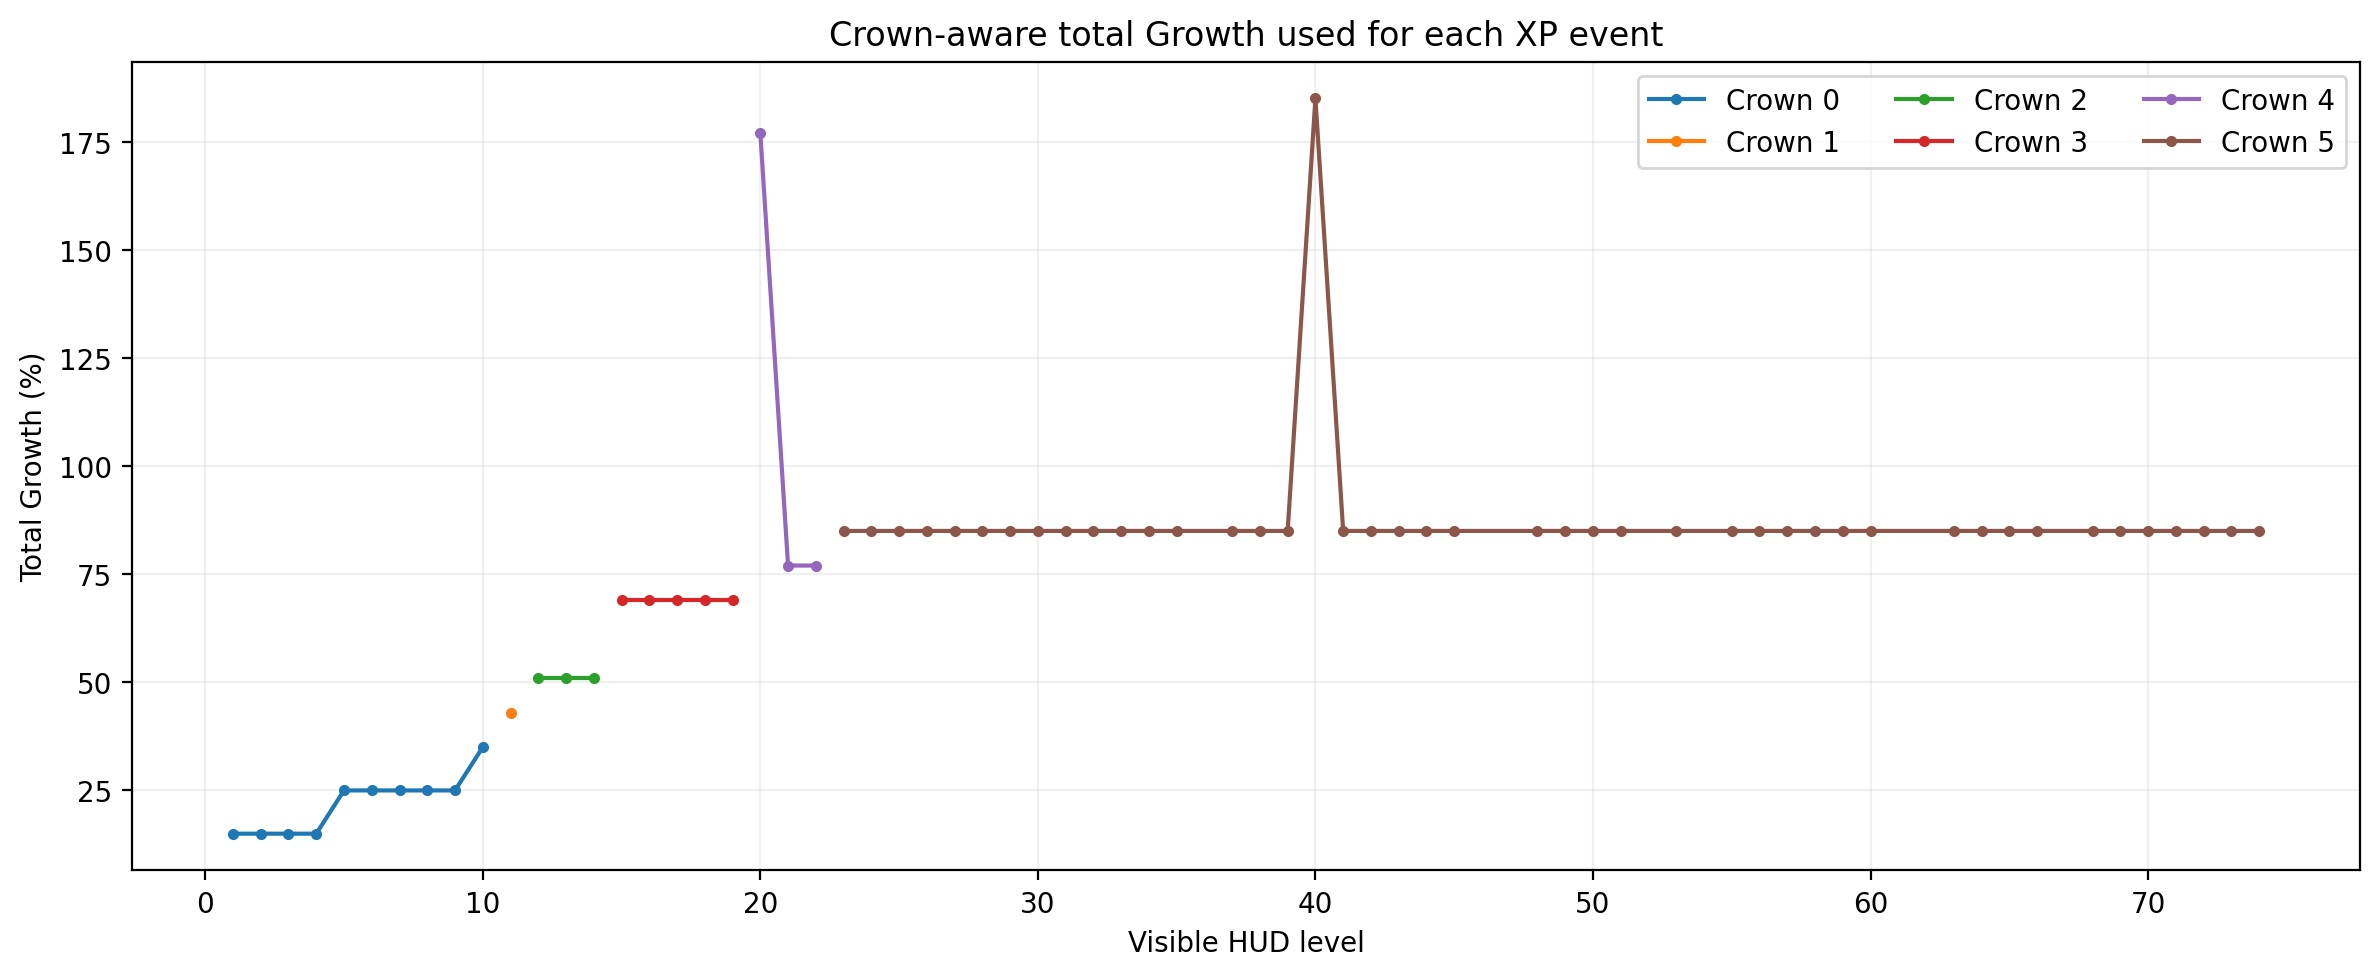

In [3]:
crown_timeline = pd.DataFrame({
    "Crown level": range(6),
    "Activation frame": [0, *helpers.VIDEO4_CROWN_ACTIVATION_FRAMES],
    "Video time": ["0:00.000", "3:04.333", "3:20.867", "4:05.000", "5:48.300", "8:11.967"],
    "Crown Growth (%)": [0, 8, 16, 24, 32, 40],
})
display(crown_timeline)

growth_by_level = (
    events.groupby(["hud_level", "crown_level_before"], as_index=False)
    .agg(
        total_growth_percent=("total_growth_percent", "median"),
        events=("event_id", "size"),
    )
)
fig, ax = plt.subplots(figsize=(12, 5))
for crown_level, group in growth_by_level.groupby("crown_level_before"):
    ax.plot(
        group["hud_level"], group["total_growth_percent"], marker="o",
        linewidth=1.5, markersize=3, label=f"Crown {int(crown_level)}",
    )
ax.set(
    title="Crown-aware total Growth used for each XP event",
    xlabel="Visible HUD level", ylabel="Total Growth (%)",
)
ax.grid(alpha=0.18)
ax.legend(ncol=3)
fig.tight_layout()
CROWN_GROWTH_PNG = OUTPUT / "xp_weak_visual_crown_growth_timeline.png"
CROWN_GROWTH_JPG = OUTPUT / "xp_weak_visual_crown_growth_timeline.jpg"
fig.savefig(CROWN_GROWTH_PNG, dpi=200, bbox_inches="tight")
fig.savefig(CROWN_GROWTH_JPG, dpi=200, bbox_inches="tight", pil_kwargs={"quality": 94})
plt.close(fig)
crown_timeline.to_csv(OUTPUT / "xp_weak_visual_crown_timeline.csv", index=False)
growth_by_level.to_csv(OUTPUT / "xp_weak_visual_growth_by_level.csv", index=False)
display(NotebookImage(filename=str(CROWN_GROWTH_JPG), width=1100))

## Features used by the model

The random-forest classifier learns blue versus green from measurements available before the
final decision:

| Feature family | Examples | Why it helps |
|---|---|---|
| XP physics | log XP increase, normalized base XP, local-step ratio | Makes pickup magnitude comparable across levels |
| Growth state | HUD level, Crown level, Crown Growth, total Growth | Prevents Crown upgrades from imitating higher-value colors |
| Trajectory | track count, maximum/mean score, weak-track colors | Captures gems moving toward Imelda over several frames |
| A/B appearance | blue/green/red detections in Frames A and B | Records evidence immediately before and at pickup |
| Disappearance | per-color disappeared detections | Supports a gem vanishing at the pickup boundary |
| Ambiguity | unmatched per-color candidates | Warns that another visible gem may explain the jump |
| Measurement quality | HUD-level OCR confidence | Reduces reliance on uncertain level normalization |

Strong final trajectory labels, final color evidence, human counts, and percentage-assisted
labels are not model features. Red is applied afterward only when normalized XP exceeds
`9.50`, a weak red trajectory exists, and its score is at least `0.76`.

Continuous positive quantities are log-transformed where appropriate because XP changes and
trajectory measurements are strongly right-skewed. Missing numeric values are median-imputed
inside each training fold, preventing held-out events from influencing preprocessing.

In [4]:
feature_preview = helpers.feature_frame(reference, nearest_only=False)
feature_table = pd.DataFrame(
    {
        "Feature": feature_preview.columns,
        "Missing values": feature_preview.isna().sum().to_numpy(),
        "Reference minimum": feature_preview.min(numeric_only=True).round(4).to_numpy(),
        "Reference maximum": feature_preview.max(numeric_only=True).round(4).to_numpy(),
    }
)
display(feature_table)

,Feature,Missing values,Reference minimum,Reference maximum
0,hud_level,0,2.0000,74.0000
1,log_xp_increase_percent,0,-1.3655,1.4773
2,log_level_normalized_gain,0,-0.9570,1.8501
3,crown_level_before,0,0.0000,5.0000
4,crown_growth_percent,0,0.0000,40.0000
5,total_growth_percent,0,15.0000,185.0000
6,log_jump_step_ratio,0,-0.9431,1.9362
7,hud_level_ocr_confidence,0,0.0000,1.0000
8,count_trajectory_track_count,0,0.0000,8.0000
9,count_trajectory_max_score,0,0.0000,0.9757


## Out-of-fold validation

The 1,254 visual references are divided into three stratified folds. For each fold, the model
trains on the other two folds and predicts the held-out fold. Therefore, every number in the
confusion matrix comes from a prediction on an event that was not used to fit that model.

Red is not included in the statistical blue/green fit because three examples cannot support
a stable learned red class. The guarded red rule is evaluated on the held-out events alongside
the statistical predictions.

In [5]:
truth = reference["reference_color"].to_numpy()
features = helpers.feature_frame(reference, nearest_only=False)
splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=20260802)
oof_prediction = np.full(len(reference), "", dtype=object)
oof_probability = np.zeros((len(reference), len(helpers.COLORS)), dtype=float)
fold_number = np.zeros(len(reference), dtype=int)

for fold, (train_indices, test_indices) in enumerate(
    splitter.split(features, truth), start=1
):
    model = helpers.multimodal_pipeline()
    usable_train = train_indices[truth[train_indices] != "red"]
    model.fit(features.iloc[usable_train], truth[usable_train])
    fold_predictions, fold_probabilities = helpers.multimodal_predict(
        model, reference.iloc[test_indices]
    )
    oof_prediction[test_indices] = fold_predictions
    oof_probability[test_indices] = fold_probabilities
    fold_number[test_indices] = fold

oof_confidence = oof_probability.max(axis=1)
accuracy = accuracy_score(truth, oof_prediction)
balanced_accuracy = balanced_accuracy_score(truth, oof_prediction)
macro_f1 = f1_score(
    truth, oof_prediction, labels=helpers.COLORS, average="macro", zero_division=0
)
precision, recall, color_f1, support = precision_recall_fscore_support(
    truth, oof_prediction, labels=helpers.COLORS, zero_division=0
)

validation_summary = pd.DataFrame(
    [
        {"Metric": "Overall accuracy", "Value": accuracy},
        {"Metric": "Balanced accuracy", "Value": balanced_accuracy},
        {"Metric": "Macro F1", "Value": macro_f1},
    ]
)
color_metrics = pd.DataFrame(
    {
        "Color": [color.title() for color in helpers.COLORS],
        "Precision": precision,
        "Recall": recall,
        "F1": color_f1,
        "Support": support,
    }
)
display(validation_summary.style.format({"Value": "{:.2%}"}))
display(color_metrics.style.format({"Precision": "{:.2%}", "Recall": "{:.2%}", "F1": "{:.2%}"}))

validation_predictions = reference[
    ["event_id", "event_key", "video_time_stamp", "hud_level",
     "crown_level_before", "crown_growth_percent", "total_growth_percent",
     "xp_bar_increase_percent", "estimated_base_xp_gain_crown_adjusted",
     "level_normalized_xp_gain", "color_evidence"]
].copy()
validation_predictions["fold"] = fold_number
validation_predictions["visual_reference_color"] = truth
validation_predictions["model_prediction"] = oof_prediction
validation_predictions["model_confidence"] = oof_confidence.round(4)
for color_index, color in enumerate(helpers.COLORS):
    validation_predictions[f"probability_{color}"] = oof_probability[:, color_index].round(4)
validation_predictions["correct"] = (truth == oof_prediction).astype(int)
validation_predictions.to_csv(OUTPUT / "xp_weak_visual_validation_predictions.csv", index=False)

,Metric,Value
0,Overall accuracy,96.89%
1,Balanced accuracy,86.65%
2,Macro F1,86.07%


,Color,Precision,Recall,F1,Support
0,Blue,98.74%,97.22%,97.98%,971
1,Green,91.19%,96.07%,93.57%,280
2,Red,66.67%,66.67%,66.67%,3


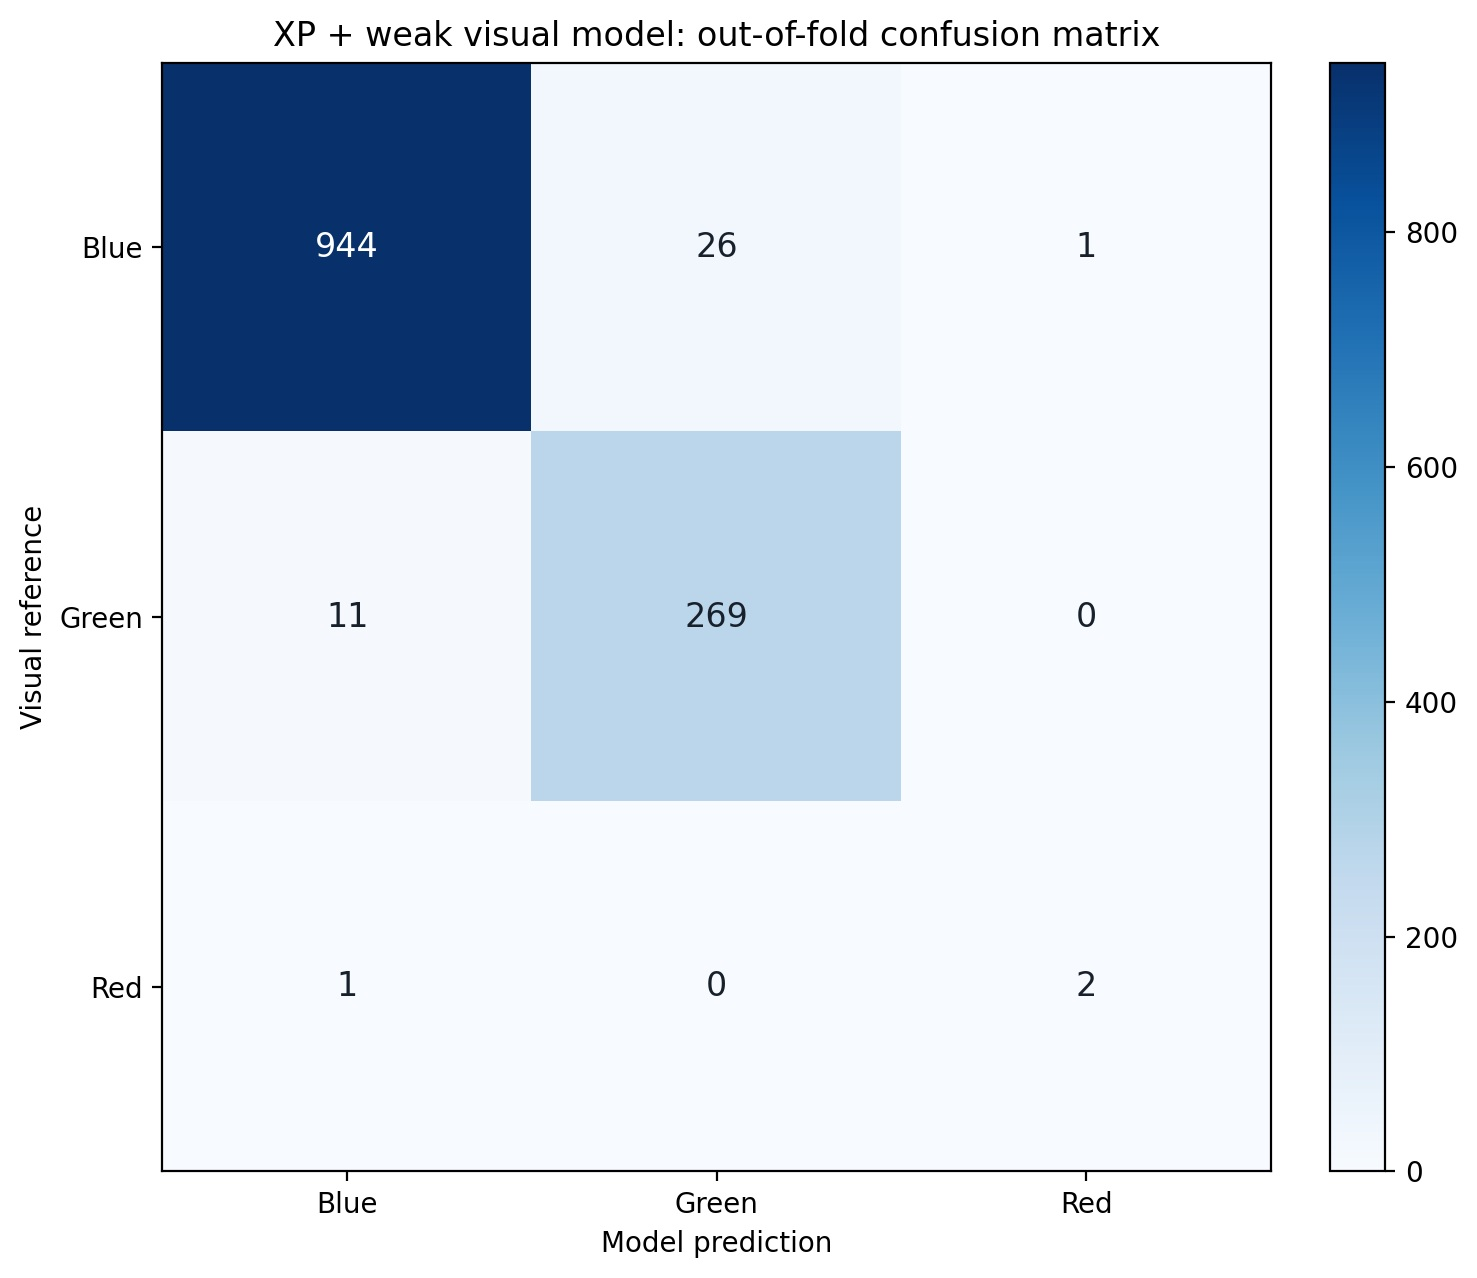

,Predicted Blue,Predicted Green,Predicted Red
Actual Blue,944,26,1
Actual Green,11,269,0
Actual Red,1,0,2


,Metric,Before Crown correction,Crown-aware model,Change
0,Correct predictions,1212,1215,+3
1,Errors,42,39,-3
2,Overall accuracy,96.65%,96.89%,+0.0024
3,Blue predicted as green,27,26,-1
4,Green predicted as blue,13,11,-2


In [6]:
matrix = confusion_matrix(truth, oof_prediction, labels=helpers.COLORS)
fig, ax = plt.subplots(figsize=(8, 6.5))
image = ax.imshow(matrix, cmap="Blues")
for row in range(matrix.shape[0]):
    for column in range(matrix.shape[1]):
        ax.text(
            column, row, str(int(matrix[row, column])),
            ha="center", va="center", fontsize=12,
            color="white" if matrix[row, column] > matrix.max() / 2 else "#18212b",
        )
ax.set(
    title="XP + weak visual model: out-of-fold confusion matrix",
    xticks=range(3),
    xticklabels=[color.title() for color in helpers.COLORS],
    yticks=range(3),
    yticklabels=[color.title() for color in helpers.COLORS],
    xlabel="Model prediction",
    ylabel="Visual reference",
)
fig.colorbar(image, ax=ax, fraction=0.046, pad=0.04)
fig.tight_layout()
CONFUSION_PNG = OUTPUT / "xp_weak_visual_confusion_matrix.png"
CONFUSION_JPG = OUTPUT / "xp_weak_visual_confusion_matrix.jpg"
fig.savefig(CONFUSION_PNG, dpi=200, bbox_inches="tight")
fig.savefig(CONFUSION_JPG, dpi=200, bbox_inches="tight", pil_kwargs={"quality": 94})
plt.close(fig)
display(NotebookImage(filename=str(CONFUSION_JPG), width=850))

confusion_table = pd.DataFrame(
    matrix,
    index=[f"Actual {color.title()}" for color in helpers.COLORS],
    columns=[f"Predicted {color.title()}" for color in helpers.COLORS],
)
display(confusion_table)

# Frozen matrix from the immediately preceding model, before explicit Crown correction.
pre_crown_matrix = np.array([[943, 27, 1], [13, 267, 0], [1, 0, 2]])
crown_comparison = pd.DataFrame(
    {
        "Metric": [
            "Correct predictions", "Errors", "Overall accuracy",
            "Blue predicted as green", "Green predicted as blue",
        ],
        "Before Crown correction": [
            int(np.trace(pre_crown_matrix)),
            int(pre_crown_matrix.sum() - np.trace(pre_crown_matrix)),
            np.trace(pre_crown_matrix) / pre_crown_matrix.sum(),
            int(pre_crown_matrix[0, 1]), int(pre_crown_matrix[1, 0]),
        ],
        "Crown-aware model": [
            int(np.trace(matrix)), int(matrix.sum() - np.trace(matrix)),
            np.trace(matrix) / matrix.sum(),
            int(matrix[0, 1]), int(matrix[1, 0]),
        ],
    }
)
crown_comparison["Change"] = (
    crown_comparison["Crown-aware model"]
    - crown_comparison["Before Crown correction"]
)
display(crown_comparison.style.format({
    "Before Crown correction": lambda value: f"{value:.2%}" if 0 < value < 1 else f"{value:g}",
    "Crown-aware model": lambda value: f"{value:.2%}" if 0 < value < 1 else f"{value:g}",
    "Change": lambda value: f"{value:+.4f}" if abs(value) < 1 else f"{value:+g}",
}))
crown_comparison.to_csv(OUTPUT / "xp_weak_visual_crown_before_after.csv", index=False)

## Internal class-specific diagnostics

Here, **visually resolved reference** means that the computer-vision pipeline supplied a blue,
green, or red label from trajectory/disappearance evidence. This name is clearer than
"observed," which could be confused with training data. Every reference is evaluated with an
out-of-fold prediction from a model that did not train on that event.

This is an internal validation against visual reference labels, not an independent human-coded
test. The count-bias table compares the number of events assigned to each color; the three
one-versus-rest matrices show whether each color was present at the individual-event level.
Because only three visually resolved reference events are red, red estimates are descriptive
and statistically unstable.

,Color,Visual reference total,Predicted total,Count error,Precision,Recall,F1,Support
0,Blue,971,956,-15,98.74%,97.22%,97.98%,971
1,Green,280,295,15,91.19%,96.07%,93.57%,280
2,Red,3,3,0,66.67%,66.67%,66.67%,3


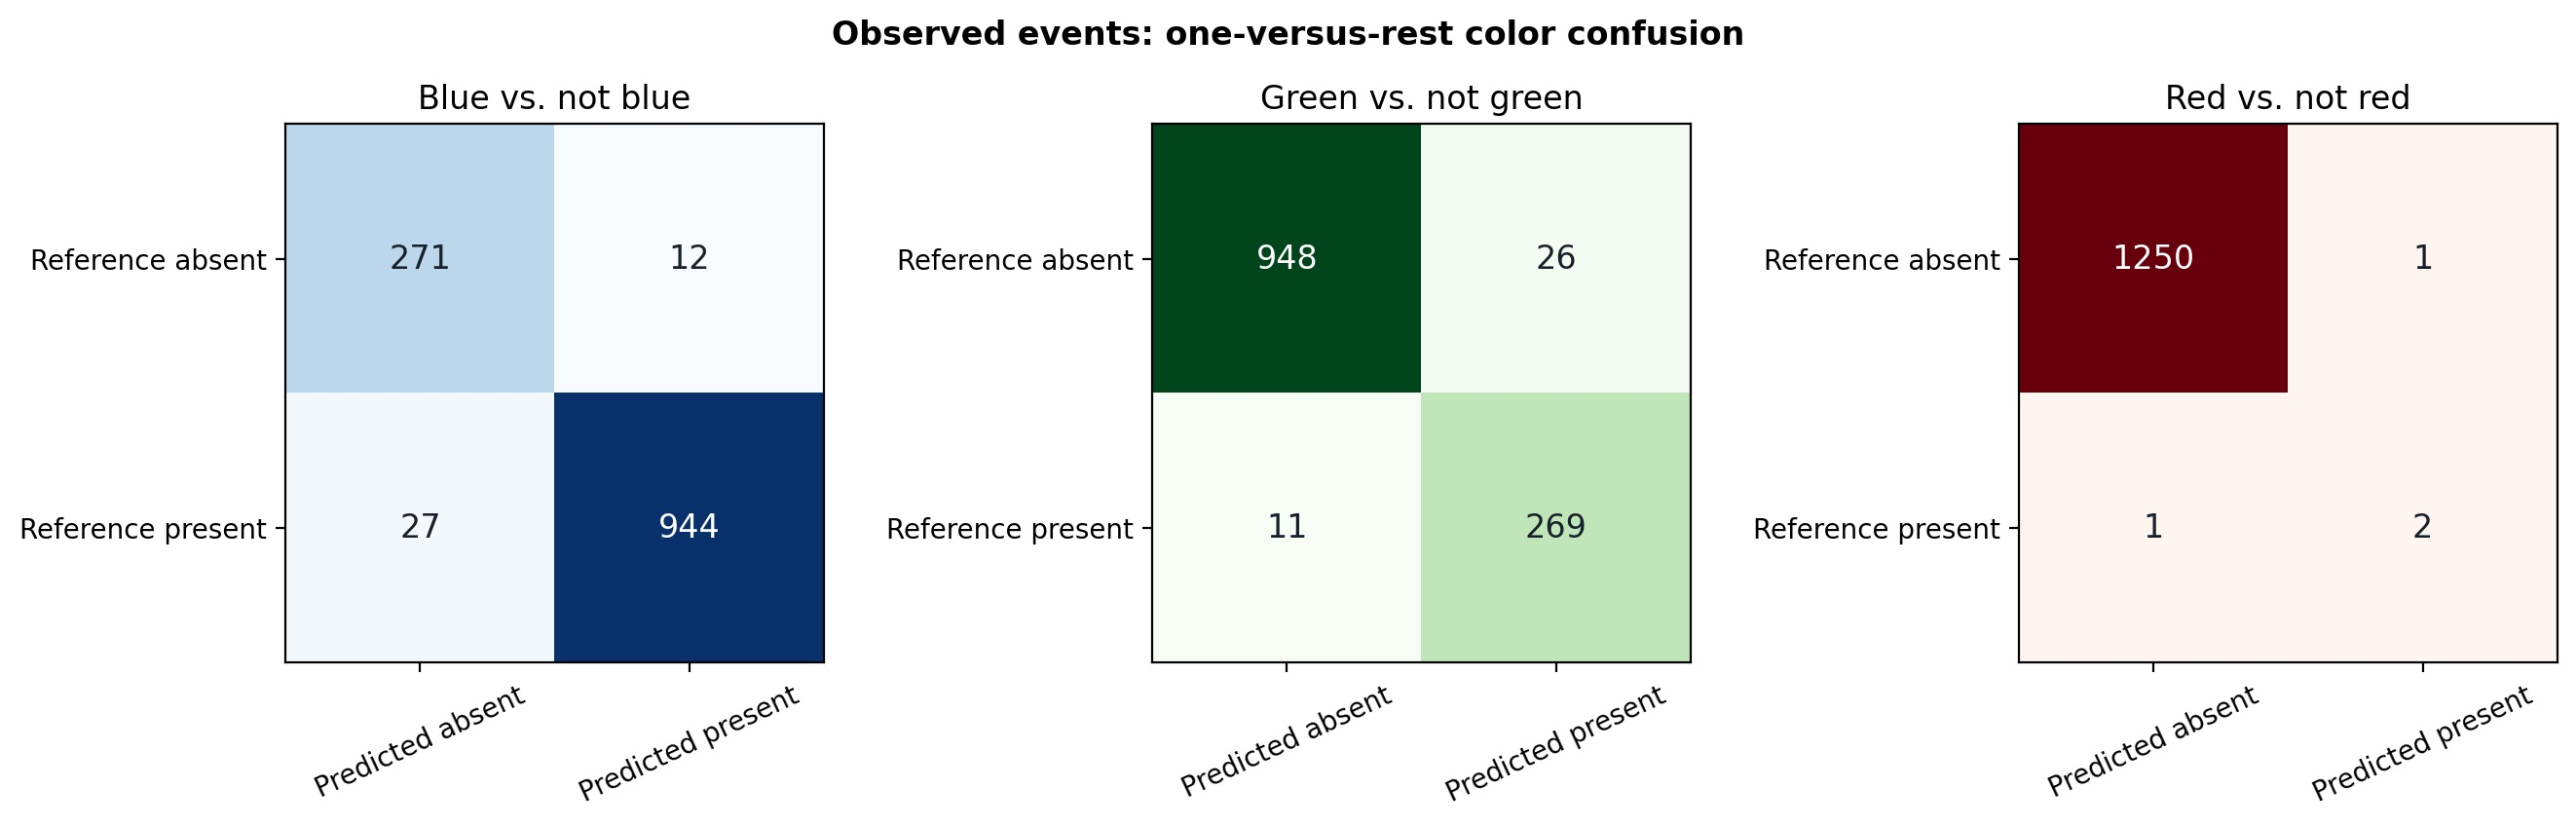

In [7]:
observed_count_metrics = []
observed_presence_tables = {}

for color in helpers.COLORS:
    actual_binary = (truth == color).astype(int)
    predicted_binary = (oof_prediction == color).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        actual_binary, predicted_binary, labels=[0, 1]
    ).ravel()
    actual_total = int(actual_binary.sum())
    predicted_total = int(predicted_binary.sum())
    observed_count_metrics.append(
        {
            "Color": color.title(),
            "Visual reference total": actual_total,
            "Predicted total": predicted_total,
            "Count error": predicted_total - actual_total,
            "Precision": tp / (tp + fp) if tp + fp else 0.0,
            "Recall": tp / (tp + fn) if tp + fn else 0.0,
            "F1": 2 * tp / (2 * tp + fp + fn) if 2 * tp + fp + fn else 0.0,
            "Support": actual_total,
        }
    )
    observed_presence_tables[color] = np.array([[tn, fp], [fn, tp]])

observed_count_metrics = pd.DataFrame(observed_count_metrics)
display(observed_count_metrics.style.format({
    "Precision": "{:.2%}", "Recall": "{:.2%}", "F1": "{:.2%}"
}))

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.2))
color_maps = {"blue": "Blues", "green": "Greens", "red": "Reds"}
for ax, color in zip(axes, helpers.COLORS):
    table = observed_presence_tables[color]
    image = ax.imshow(table, cmap=color_maps[color])
    for row in range(2):
        for column in range(2):
            value = int(table[row, column])
            ax.text(
                column, row, str(value), ha="center", va="center", fontsize=12,
                color="white" if value > table.max() / 2 else "#18212b",
            )
    ax.set(
        title=f"{color.title()} vs. not {color}",
        xticks=[0, 1], xticklabels=["Predicted absent", "Predicted present"],
        yticks=[0, 1], yticklabels=["Reference absent", "Reference present"],
    )
    ax.tick_params(axis="x", rotation=25)
fig.suptitle("Observed events: one-versus-rest color confusion", fontweight="bold")
fig.tight_layout()
OBSERVED_PRESENCE_PNG = OUTPUT / "xp_weak_visual_observed_color_presence.png"
OBSERVED_PRESENCE_JPG = OUTPUT / "xp_weak_visual_observed_color_presence.jpg"
fig.savefig(OBSERVED_PRESENCE_PNG, dpi=200, bbox_inches="tight")
fig.savefig(OBSERVED_PRESENCE_JPG, dpi=200, bbox_inches="tight", pil_kwargs={"quality": 94})
plt.close(fig)
display(NotebookImage(filename=str(OBSERVED_PRESENCE_JPG), width=1100))

observed_count_metrics.to_csv(
    OUTPUT / "xp_weak_visual_observed_color_metrics.csv", index=False
)
for color, table in observed_presence_tables.items():
    pd.DataFrame(
        table,
        index=["Reference absent", "Reference present"],
        columns=["Predicted absent", "Predicted present"],
    ).to_csv(OUTPUT / f"xp_weak_visual_observed_{color}_presence_matrix.csv")

## Train the final candidate model

The final model trains on all 1,251 usable blue and green visual references. It then predicts
the 849 events whose production color is unresolved.

### Decision rules

1. The random forest predicts blue or green from Crown-aware XP and weak visual features.
2. Red is accepted only by the guarded high-XP plus red-trajectory rule.
3. A saturated level-up event cannot use XP magnitude because the bar does not overflow.
4. A saturated event receives a color only when exactly one trajectory has exactly one color,
   both maximum and mean scores are at least 0.90, and the track disappears at the A/B boundary.
5. If color is plausible but exact quantity is not identifiable, the event remains unresolved
   and receives only `likely_color`.

Every assignment is a **candidate model output**. It does not overwrite the conservative
production detector result.

In [8]:
final_model = helpers.multimodal_pipeline()
non_red_reference = reference["reference_color"].ne("red")
final_model.fit(
    helpers.feature_frame(reference.loc[non_red_reference], nearest_only=False),
    reference.loc[non_red_reference, "reference_color"],
)
model_prediction, model_probability = helpers.multimodal_predict(final_model, unresolved)
model_confidence = model_probability.max(axis=1)

unresolved_predictions = unresolved[
    [
        "event_id", "event_key", "frame_a", "frame_b", "video_time_a", "video_time_b",
        "video_time_stamp", "hud_level", "hud_level_source", "hud_level_ocr_confidence",
        "hud_level_ocr_accepted", "reset_inferred_level", "inferred_level",
        "crown_level_before", "crown_growth_percent", "imelda_growth_percent",
        "base_growth_powerup_percent", "level_spike_growth_percent",
        "total_growth_percent", "growth_multiplier_crown_adjusted",
        "xp_delta_pixels", "xp_bar_increase_percent",
        "estimated_base_xp_gain_crown_adjusted",
        "level_normalized_xp_gain", "xp_bar_saturated", "xp_event_temporally_isolated",
        "count_trajectory_colors", "count_trajectory_track_count",
        "count_trajectory_max_score", "count_trajectory_mean_score",
        "count_trajectory_start_frames", "count_trajectory_end_frames",
        "count_trajectory_disappearance_frames", "count_trajectory_scores",
        "unmatched_candidate_blue", "unmatched_candidate_green",
        "unmatched_candidate_red",
        "pair_image", "percentage_assist_gate_reason",
    ]
].copy()
unresolved_predictions["model_prediction"] = model_prediction
unresolved_predictions["model_confidence"] = model_confidence.round(4)
for color_index, color in enumerate(helpers.COLORS):
    unresolved_predictions[f"probability_{color}"] = model_probability[:, color_index].round(4)
unresolved_predictions["level_up_visual_rule_applied"] = (
    unresolved_predictions["xp_bar_saturated"].eq(1)
    & unresolved_predictions["model_prediction"].isin(helpers.COLORS)
)
unresolved_predictions["model_status"] = np.select(
    [
        unresolved_predictions["model_prediction"].eq(""),
        unresolved_predictions["level_up_visual_rule_applied"],
        unresolved_predictions["model_prediction"].eq("red"),
        unresolved_predictions["model_confidence"].lt(0.80),
    ],
    [
        "saturated_unresolved", "level_up_visual_assignment",
        "red_review_required", "low_confidence_review",
    ],
    default="candidate_assignment",
)

# An unresolved exact count can still carry a likely color. This visual-only label does
# not convert the event into a resolved count.
likely_color, likely_color_confidence, likely_color_reason = (
    helpers.saturated_likely_color(unresolved_predictions)
)
still_saturated = unresolved_predictions["model_status"].eq("saturated_unresolved")
unresolved_predictions["likely_color"] = np.where(
    still_saturated, likely_color, unresolved_predictions["model_prediction"]
)
unresolved_predictions["likely_color_confidence"] = np.where(
    still_saturated, likely_color_confidence, unresolved_predictions["model_confidence"]
).round(4)
unresolved_predictions["likely_color_reason"] = np.where(
    still_saturated, likely_color_reason, "resolved_model_assignment"
)
unresolved_predictions.to_csv(
    OUTPUT / "xp_weak_visual_unresolved_predictions.csv", index=False
)

outcome_counts = {
    color: int((model_prediction == color).sum()) for color in helpers.COLORS
}
outcome_counts["unresolved"] = int((model_prediction == "").sum())
outcome_table = pd.DataFrame(
    {
        "Candidate result": ["Blue", "Green", "Red", "Still unresolved"],
        "Events": [
            outcome_counts["blue"], outcome_counts["green"],
            outcome_counts["red"], outcome_counts["unresolved"],
        ],
    }
)
display(outcome_table)
display(unresolved_predictions["model_status"].value_counts().rename_axis("Review status").reset_index(name="Events"))
display(
    unresolved_predictions.loc[still_saturated, [
        "event_id", "video_time_stamp", "count_trajectory_colors",
        "count_trajectory_scores", "likely_color", "likely_color_confidence",
        "likely_color_reason", "model_status",
    ]]
)

assert sum(outcome_counts.values()) == len(unresolved)
assert outcome_counts["unresolved"] == int(still_saturated.sum())
assert unresolved_predictions.loc[still_saturated, "likely_color"].ne("").all()

,Candidate result,Events
0,Blue,640
1,Green,203
2,Red,1
3,Still unresolved,5


,Review status,Events
0,low_confidence_review,454
1,candidate_assignment,388
2,saturated_unresolved,5
3,level_up_visual_assignment,1
4,red_review_required,1


,event_id,video_time_stamp,count_trajectory_colors,count_trajectory_scores,likely_color,likely_color_confidence,likely_color_reason,model_status
379,380,3:29.433,blue|blue,0.909|0.723,blue,1.0000,trajectory_score_vote,saturated_unresolved
2010,2011,14:46.367,NaN,NaN,green,1.0000,unmatched_candidate_vote,saturated_unresolved
2402,2403,16:10.367,blue|blue,0.784|0.750,blue,1.0000,trajectory_score_vote,saturated_unresolved
2423,2424,16:13.467,blue|blue|blue,0.840|0.810|0.764,blue,1.0000,trajectory_score_vote,saturated_unresolved
2914,2915,18:12.100,green|blue,0.829|0.833,blue,0.5012,trajectory_score_vote,saturated_unresolved


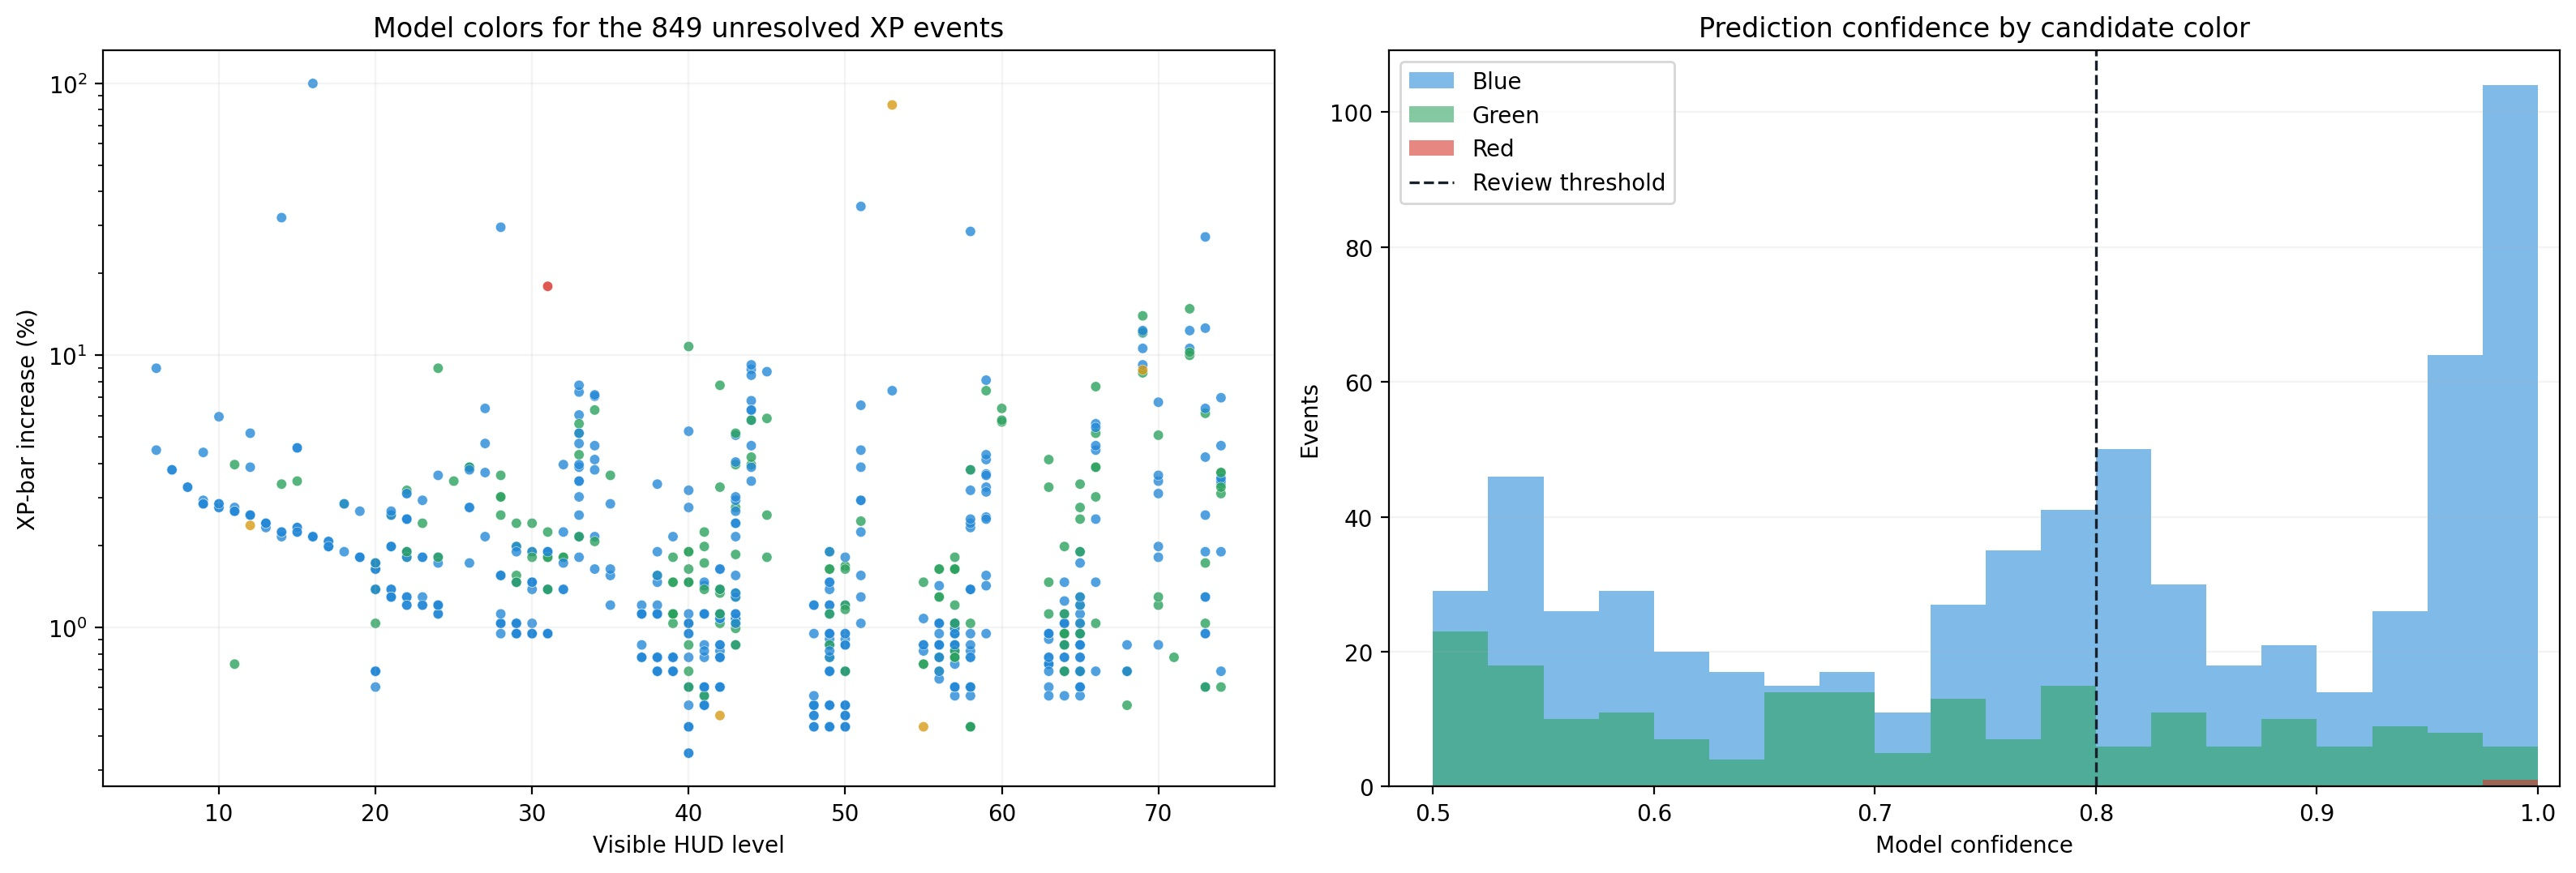

In [9]:
prediction_colors = [
    helpers.DISPLAY_COLORS.get(value, helpers.DISPLAY_COLORS["unresolved"])
    for value in model_prediction
]
fig, axes = plt.subplots(1, 2, figsize=(16, 5.5))

axes[0].scatter(
    unresolved["hud_level"], unresolved["xp_bar_increase_percent"],
    c=prediction_colors, s=20, alpha=0.80, edgecolors="white", linewidths=0.2,
)
axes[0].set_yscale("log")
axes[0].set(
    title="Model colors for the 849 unresolved XP events",
    xlabel="Visible HUD level",
    ylabel="XP-bar increase (%)",
)
axes[0].grid(alpha=0.15)

for color in helpers.COLORS:
    selected = model_prediction == color
    axes[1].hist(
        model_confidence[selected], bins=np.linspace(0.5, 1.0, 21),
        alpha=0.58, color=helpers.DISPLAY_COLORS[color], label=color.title(),
    )
axes[1].axvline(0.80, color="#18212b", linestyle="--", linewidth=1.2, label="Review threshold")
axes[1].set(
    title="Prediction confidence by candidate color",
    xlabel="Model confidence",
    ylabel="Events",
    xlim=(0.48, 1.01),
)
axes[1].legend()
axes[1].grid(axis="y", alpha=0.15)

fig.tight_layout()
OUTCOME_PNG = OUTPUT / "xp_weak_visual_unresolved_outcomes.png"
OUTCOME_JPG = OUTPUT / "xp_weak_visual_unresolved_outcomes.jpg"
fig.savefig(OUTCOME_PNG, dpi=200, bbox_inches="tight")
fig.savefig(OUTCOME_JPG, dpi=200, bbox_inches="tight", pil_kwargs={"quality": 94})
plt.close(fig)
display(NotebookImage(filename=str(OUTCOME_JPG), width=1250))

## What the model learned

Feature importance describes how much each measurement contributed to splitting blue and
green reference events. Importance does not prove causality, and correlated detection counts
can share importance. The separate red guard is not represented in this blue/green random
forest chart.

,Feature,Importance
0,weak_track_green_count,22.93%
1,unmatched_candidate_green,17.13%
2,log_level_normalized_gain,12.94%
3,disappeared_blue,12.49%
4,log_jump_step_ratio,8.24%
5,disappeared_green,6.08%
6,unmatched_candidate_blue,3.96%
7,detections_a_green,3.00%
8,count_trajectory_max_score,2.28%
9,count_trajectory_mean_score,1.87%


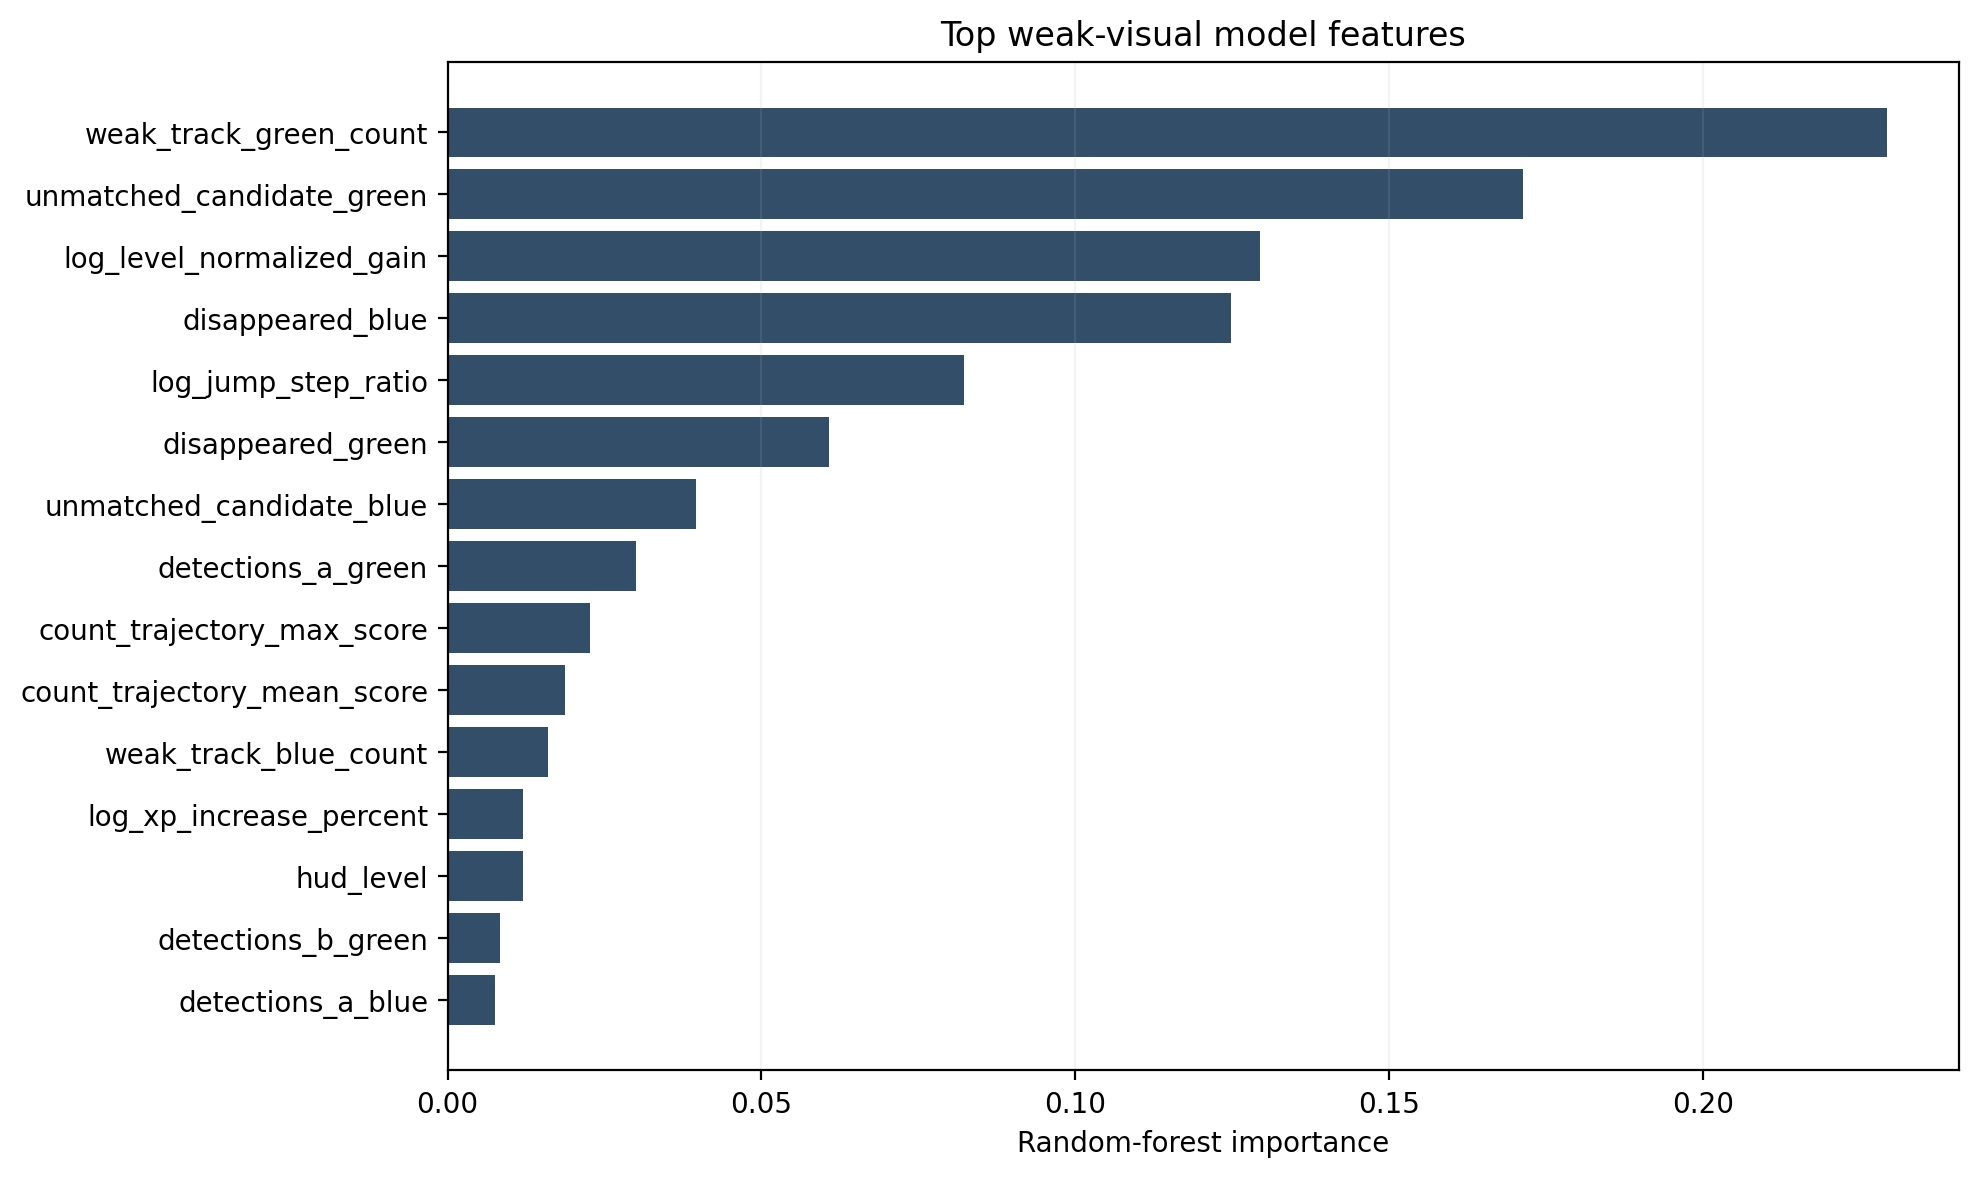

In [10]:
feature_names = helpers.feature_frame(reference, nearest_only=False).columns
forest = final_model.named_steps["classifier"]
feature_importance = (
    pd.DataFrame({"Feature": feature_names, "Importance": forest.feature_importances_})
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance.head(15).style.format({"Importance": "{:.2%}"}))

fig, ax = plt.subplots(figsize=(10, 6))
top_features = feature_importance.head(15).sort_values("Importance")
ax.barh(top_features["Feature"], top_features["Importance"], color="#334e68")
ax.set(
    title="Top weak-visual model features",
    xlabel="Random-forest importance",
    ylabel="",
)
ax.grid(axis="x", alpha=0.15)
fig.tight_layout()
IMPORTANCE_PNG = OUTPUT / "xp_weak_visual_feature_importance.png"
IMPORTANCE_JPG = OUTPUT / "xp_weak_visual_feature_importance.jpg"
fig.savefig(IMPORTANCE_PNG, dpi=200, bbox_inches="tight")
fig.savefig(IMPORTANCE_JPG, dpi=200, bbox_inches="tight", pil_kwargs={"quality": 94})
plt.close(fig)
display(NotebookImage(filename=str(IMPORTANCE_JPG), width=1000))

## Event-level and interval candidate outputs

The following tables apply the model prediction only to rows currently marked unresolved.
Already resolved colors remain unchanged. A blank prediction leaves the event unresolved.
These columns use a `model_` prefix so they cannot be mistaken for production detector counts.

### Important output fields

| Field | Meaning |
|---|---|
| `xp_weak_visual_prediction` | Candidate blue, green, or red assignment |
| `xp_weak_visual_confidence` | Random-forest score; not a calibrated probability |
| `model_unresolved_collected_gems` | Quantity still not assigned to an exact color |
| `likely_color` | Best color hypothesis when exact quantity remains unresolved |
| `crown_level_before` | Crown level active before the XP event |
| `total_growth_percent` | PowerUp + Imelda + Crown + temporary level spike |
| `estimated_base_xp_gain_crown_adjusted` | XP estimate after dividing out total Growth |
| `level_normalized_xp_gain` | Crown-adjusted XP estimate after pixel calibration |

Per-second and five-second files are aggregations of the same event table. They do not create
new detections or provide additional ground truth.

In [11]:
model_events = events.copy()
prediction_map = unresolved_predictions.set_index("event_id")["model_prediction"]
confidence_map = unresolved_predictions.set_index("event_id")["model_confidence"]
likely_map = unresolved_predictions.set_index("event_id")["likely_color"]
likely_confidence_map = unresolved_predictions.set_index("event_id")["likely_color_confidence"]
model_events["xp_weak_visual_prediction"] = model_events["event_id"].map(prediction_map).fillna("")
model_events["xp_weak_visual_confidence"] = model_events["event_id"].map(confidence_map)
model_events["likely_color"] = model_events["event_id"].map(likely_map).fillna("")
model_events["likely_color_confidence"] = model_events["event_id"].map(likely_confidence_map)
assigned = model_events["xp_weak_visual_prediction"].isin(helpers.COLORS)
for color in helpers.COLORS:
    model_events[f"model_collected_{color}_gems"] = (
        model_events[f"collected_{color}_gems"]
        + model_events["xp_weak_visual_prediction"].eq(color).astype(int)
    )
model_events["model_unresolved_collected_gems"] = (
    model_events["unresolved_collected_gems"] - assigned.astype(int)
)
model_events["model_collected_gems_total"] = model_events[
    [
        "model_collected_blue_gems", "model_collected_green_gems",
        "model_collected_red_gems", "model_unresolved_collected_gems",
    ]
].sum(axis=1)

# Likely-color counts allocate one confirmed but quantity-ambiguous pickup to its most
# plausible color. Exact model counts above remain unchanged and unresolved.
for color in helpers.COLORS:
    model_events[f"likely_collected_{color}_gems"] = (
        model_events[f"model_collected_{color}_gems"]
        + (
            model_events["model_unresolved_collected_gems"].gt(0)
            & model_events["likely_color"].eq(color)
        ).astype(int)
    )


def aggregate_model_events(frame, seconds):
    duration = int(np.ceil(events["video_time_b"].max()))
    rows = []
    for start in range(0, duration + 1, seconds):
        end = start + seconds
        subset = frame.loc[
            frame["video_time_b"].ge(start) & frame["video_time_b"].lt(end)
        ]
        rows.append(
            {
                "time_stamp": (
                    f"{start // 60}:{start % 60:02d}-"
                    f"{end // 60}:{end % 60:02d}"
                ),
                "interval_start_second": start,
                "interval_end_second": end,
                "xp_jump_events": len(subset),
                "model_collected_blue_gems": int(subset["model_collected_blue_gems"].sum()),
                "model_collected_green_gems": int(subset["model_collected_green_gems"].sum()),
                "model_collected_red_gems": int(subset["model_collected_red_gems"].sum()),
                "model_unresolved_collected_gems": int(subset["model_unresolved_collected_gems"].sum()),
                "model_collected_gems_total": int(subset["model_collected_gems_total"].sum()),
                "model_assigned_events": int(subset["xp_weak_visual_prediction"].isin(helpers.COLORS).sum()),
                "model_mean_confidence": (
                    round(float(subset.loc[subset["xp_weak_visual_prediction"].isin(helpers.COLORS), "xp_weak_visual_confidence"].mean()), 4)
                    if subset["xp_weak_visual_prediction"].isin(helpers.COLORS).any()
                    else np.nan
                ),
                "likely_collected_blue_gems": int(subset["likely_collected_blue_gems"].sum()),
                "likely_collected_green_gems": int(subset["likely_collected_green_gems"].sum()),
                "likely_collected_red_gems": int(subset["likely_collected_red_gems"].sum()),
                "likely_color_events": int(
                    (subset["model_unresolved_collected_gems"].gt(0) & subset["likely_color"].isin(helpers.COLORS)).sum()
                ),
                "event_ids": "|".join(str(int(value)) for value in subset["event_id"]),
            }
        )
    return pd.DataFrame(rows)


per_second_model = aggregate_model_events(model_events, 1)
five_second_model = aggregate_model_events(model_events, 5)
model_events.to_csv(OUTPUT / "xp_weak_visual_all_events.csv", index=False)
per_second_model.to_csv(OUTPUT / "xp_weak_visual_per_second.csv", index=False)
five_second_model.to_csv(OUTPUT / "xp_weak_visual_5sec_intervals.csv", index=False)

model_totals = pd.DataFrame(
    {
        "Metric": [
            "Blue candidate pickups", "Green candidate pickups", "Red candidate pickups",
            "Still unresolved", "Total collected gems",
        ],
        "Value": [
            int(model_events["model_collected_blue_gems"].sum()),
            int(model_events["model_collected_green_gems"].sum()),
            int(model_events["model_collected_red_gems"].sum()),
            int(model_events["model_unresolved_collected_gems"].sum()),
            int(model_events["model_collected_gems_total"].sum()),
        ],
    }
)
display(model_totals)
display(five_second_model.head(12))

assert model_totals.set_index("Metric").loc["Still unresolved", "Value"] == 5
assert model_events["model_collected_gems_total"].sum() == events["collected_gems_total"].sum()
assert int(model_events["likely_collected_blue_gems"].sum()) == int(model_events["model_collected_blue_gems"].sum()) + 4
assert int(model_events["likely_collected_green_gems"].sum()) == int(model_events["model_collected_green_gems"].sum()) + 1

,Metric,Value
0,Blue candidate pickups,2625
1,Green candidate pickups,610
2,Red candidate pickups,4
3,Still unresolved,5
4,Total collected gems,3244


,time_stamp,interval_start_second,interval_end_second,xp_jump_events,model_collected_blue_gems,model_collected_green_gems,model_collected_red_gems,model_unresolved_collected_gems,model_collected_gems_total,model_assigned_events,model_mean_confidence,likely_collected_blue_gems,likely_collected_green_gems,likely_collected_red_gems,likely_color_events,event_ids
0,0:00-0:05,0,5,0,0,0,0,0,0,0,NaN,0,0,0,0,
1,0:05-0:10,5,10,1,0,1,0,0,1,0,NaN,0,1,0,0,1
2,0:10-0:15,10,15,0,0,0,0,0,0,0,NaN,0,0,0,0,
3,0:15-0:20,15,20,8,8,0,0,0,8,0,NaN,8,0,0,0,2|3|4|5|6|7|8|9
4,0:20-0:25,20,25,3,3,0,0,0,3,0,NaN,3,0,0,0,10|11|12
5,0:25-0:30,25,30,6,6,0,0,0,6,0,NaN,6,0,0,0,13|14|15|16|17|18
6,0:30-0:35,30,35,3,3,0,0,0,3,0,NaN,3,0,0,0,19|20|21
7,0:35-0:40,35,40,5,5,0,0,0,5,0,NaN,5,0,0,0,22|23|24|25|26
8,0:40-0:45,40,45,2,2,0,0,0,2,0,NaN,2,0,0,0,27|28
9,0:45-0:50,45,50,5,5,0,0,0,5,0,NaN,5,0,0,0,29|30|31|32|33


## Human-coded evaluation: first five minutes

The Gaming Content reference is used **only after prediction**, never for training or
threshold selection. Its `Actual Blue Gem Count` column contains 60 five-second totals.
Because it does not identify which individual XP event produced each count, an event-level
blue/green/red confusion matrix would be invalid. We therefore report:

- exact five-second count accuracy;
- accuracy within one gem, MAE, RMSE, bias, and total error; and
- a five-second **count-bin confusion matrix**.

Likely-color evaluation allocates one confirmed pickup per still-unresolved event to its
likely color. This evaluates the practical count estimate while preserving the event's
quantity status as unresolved.

This evaluation has 60 rows, but it is not an event-level test: each row may contain several
XP jumps and several gem colors. MAE and RMSE therefore measure five-second count error. They
must not be interpreted as the probability that one pickup was classified correctly.

,Estimate,Intervals,Exact-count accuracy,Within-one accuracy,MAE,RMSE,Bias,Human total,Predicted total,Total error
0,Exact assignments only,60,20.00%,46.67%,2.967,4.517,-0.967,704,646,-58
1,Including likely colors,60,20.00%,46.67%,2.950,4.493,-0.950,704,647,-57


,Predicted 0,Predicted 1-5,Predicted 6-10,Predicted 11-20,Predicted 21+
Actual 0,3,0,0,0,0
Actual 1-5,2,14,2,1,0
Actual 6-10,0,3,7,2,0
Actual 11-20,0,1,2,9,2
Actual 21+,0,0,0,6,6


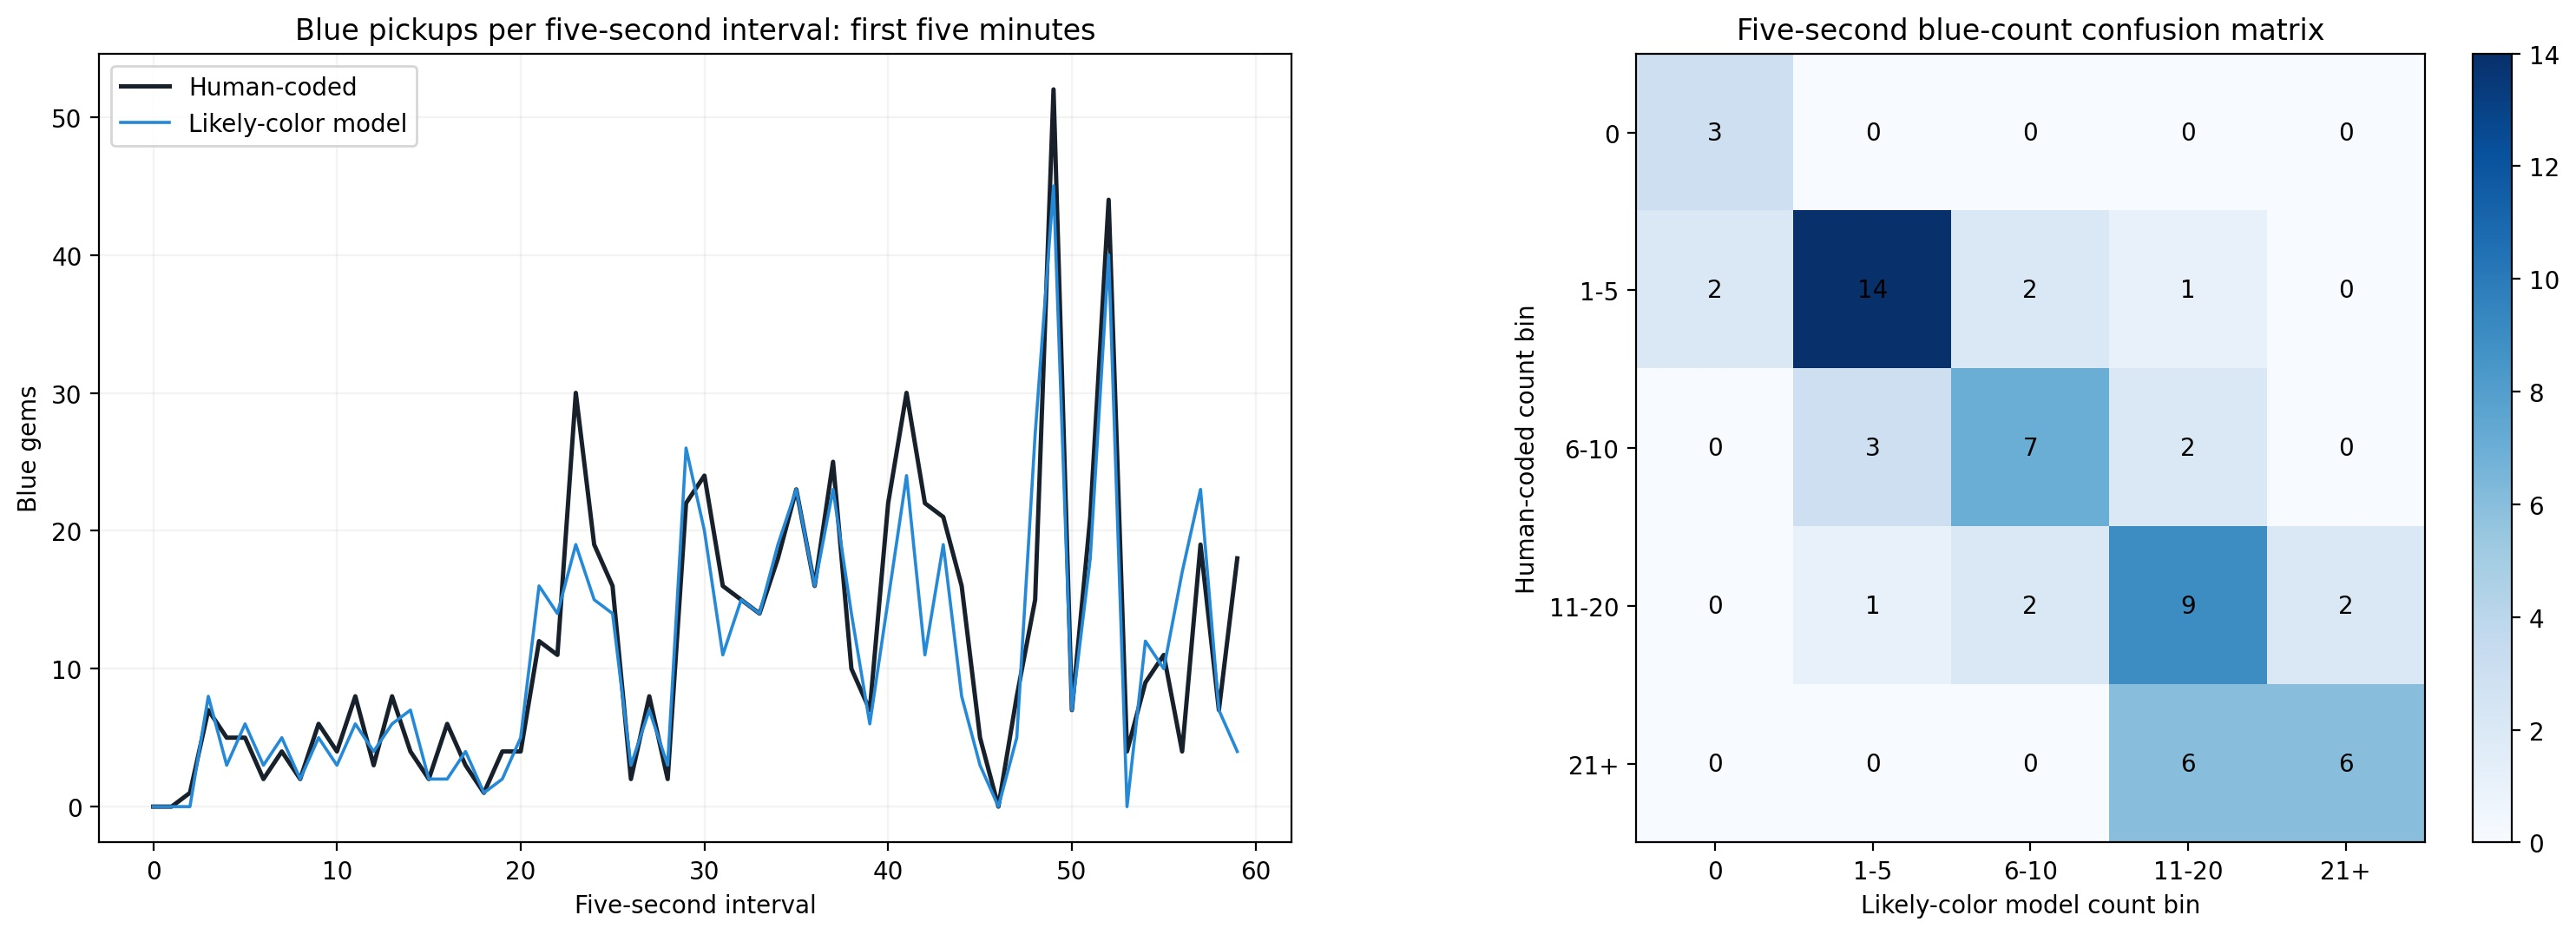

In [12]:
human_blue = pd.read_csv(HUMAN_BLUE_CSV)
human_eval = human_blue.merge(
    five_second_model[[
        "time_stamp", "model_collected_blue_gems", "likely_collected_blue_gems"
    ]],
    on="time_stamp",
    how="inner",
    validate="one_to_one",
)
human_eval["exact_error"] = (
    human_eval["model_collected_blue_gems"]
    - human_eval["actual_collected_blue_gems"]
)
human_eval["likely_error"] = (
    human_eval["likely_collected_blue_gems"]
    - human_eval["actual_collected_blue_gems"]
)


def count_metrics(actual, predicted, label):
    error = predicted - actual
    return {
        "Estimate": label,
        "Intervals": len(actual),
        "Exact-count accuracy": float(np.mean(error == 0)),
        "Within-one accuracy": float(np.mean(np.abs(error) <= 1)),
        "MAE": float(np.mean(np.abs(error))),
        "RMSE": float(np.sqrt(np.mean(error ** 2))),
        "Bias": float(np.mean(error)),
        "Human total": int(actual.sum()),
        "Predicted total": int(predicted.sum()),
        "Total error": int(predicted.sum() - actual.sum()),
    }


human_metrics = pd.DataFrame([
    count_metrics(
        human_eval["actual_collected_blue_gems"],
        human_eval["model_collected_blue_gems"],
        "Exact assignments only",
    ),
    count_metrics(
        human_eval["actual_collected_blue_gems"],
        human_eval["likely_collected_blue_gems"],
        "Including likely colors",
    ),
])
display(human_metrics.style.format({
    "Exact-count accuracy": "{:.2%}",
    "Within-one accuracy": "{:.2%}",
    "MAE": "{:.3f}", "RMSE": "{:.3f}", "Bias": "{:+.3f}",
}))

bin_labels = ["0", "1-5", "6-10", "11-20", "21+"]
bin_edges = [-0.5, 0.5, 5.5, 10.5, 20.5, np.inf]
human_eval["actual_count_bin"] = pd.cut(
    human_eval["actual_collected_blue_gems"], bin_edges, labels=bin_labels
)
human_eval["likely_count_bin"] = pd.cut(
    human_eval["likely_collected_blue_gems"], bin_edges, labels=bin_labels
)
human_count_confusion = confusion_matrix(
    human_eval["actual_count_bin"], human_eval["likely_count_bin"], labels=bin_labels
)
human_count_confusion_table = pd.DataFrame(
    human_count_confusion,
    index=[f"Actual {label}" for label in bin_labels],
    columns=[f"Predicted {label}" for label in bin_labels],
)
display(human_count_confusion_table)

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
axes[0].plot(
    human_eval.index, human_eval["actual_collected_blue_gems"],
    color="#18212b", linewidth=1.8, label="Human-coded",
)
axes[0].plot(
    human_eval.index, human_eval["likely_collected_blue_gems"],
    color=helpers.DISPLAY_COLORS["blue"], linewidth=1.3, label="Likely-color model",
)
axes[0].set(
    title="Blue pickups per five-second interval: first five minutes",
    xlabel="Five-second interval", ylabel="Blue gems",
)
axes[0].legend()
axes[0].grid(alpha=0.15)

image = axes[1].imshow(human_count_confusion, cmap="Blues")
for row in range(len(bin_labels)):
    for column in range(len(bin_labels)):
        value = int(human_count_confusion[row, column])
        axes[1].text(column, row, value, ha="center", va="center")
axes[1].set(
    title="Five-second blue-count confusion matrix",
    xticks=range(len(bin_labels)), xticklabels=bin_labels,
    yticks=range(len(bin_labels)), yticklabels=bin_labels,
    xlabel="Likely-color model count bin", ylabel="Human-coded count bin",
)
fig.colorbar(image, ax=axes[1], fraction=0.046, pad=0.04)
fig.tight_layout()
HUMAN_EVAL_PNG = OUTPUT / "xp_weak_visual_human_evaluation.png"
HUMAN_EVAL_JPG = OUTPUT / "xp_weak_visual_human_evaluation.jpg"
fig.savefig(HUMAN_EVAL_PNG, dpi=200, bbox_inches="tight")
fig.savefig(HUMAN_EVAL_JPG, dpi=200, bbox_inches="tight", pil_kwargs={"quality": 94})
plt.close(fig)

human_eval.to_csv(OUTPUT / "xp_weak_visual_human_evaluation.csv", index=False)
human_metrics.to_csv(OUTPUT / "xp_weak_visual_human_metrics.csv", index=False)
human_count_confusion_table.to_csv(
    OUTPUT / "xp_weak_visual_human_count_confusion_matrix.csv"
)
display(NotebookImage(filename=str(HUMAN_EVAL_JPG), width=1250))

assert len(human_eval) == 60

## Blue/green/red confusion across the 60 intervals

Each interval can contain several colors, so a standard single-label color confusion matrix
is not naturally defined. Two complementary views are reported:

1. **Dominant-color 3×3 matrix:** each interval is labeled by its largest blue, green, or
   red count. Intervals where either side contains zero total gems are excluded because they
   have no dominant gem color.
2. **Per-color presence matrices:** for every color and all 60 intervals, compare whether
   that color was absent or present. These retain mixed-color intervals and expose missed
   green or red pickups that a dominant-color matrix can conceal.

,Predicted Blue,Predicted Green,Predicted Red
Actual Blue,55,0,0
Actual Green,0,1,0
Actual Red,0,0,0


Dominant-color accuracy: 100.00% over 56 evaluable intervals; 4 zero-total intervals excluded.


,Color,TN,FP,FN,TP,Presence accuracy,Presence precision,Presence recall
0,Blue,3,0,2,55,96.67%,100.00%,96.49%
1,Green,35,3,5,17,86.67%,85.00%,77.27%
2,Red,59,0,1,0,98.33%,nan%,0.00%


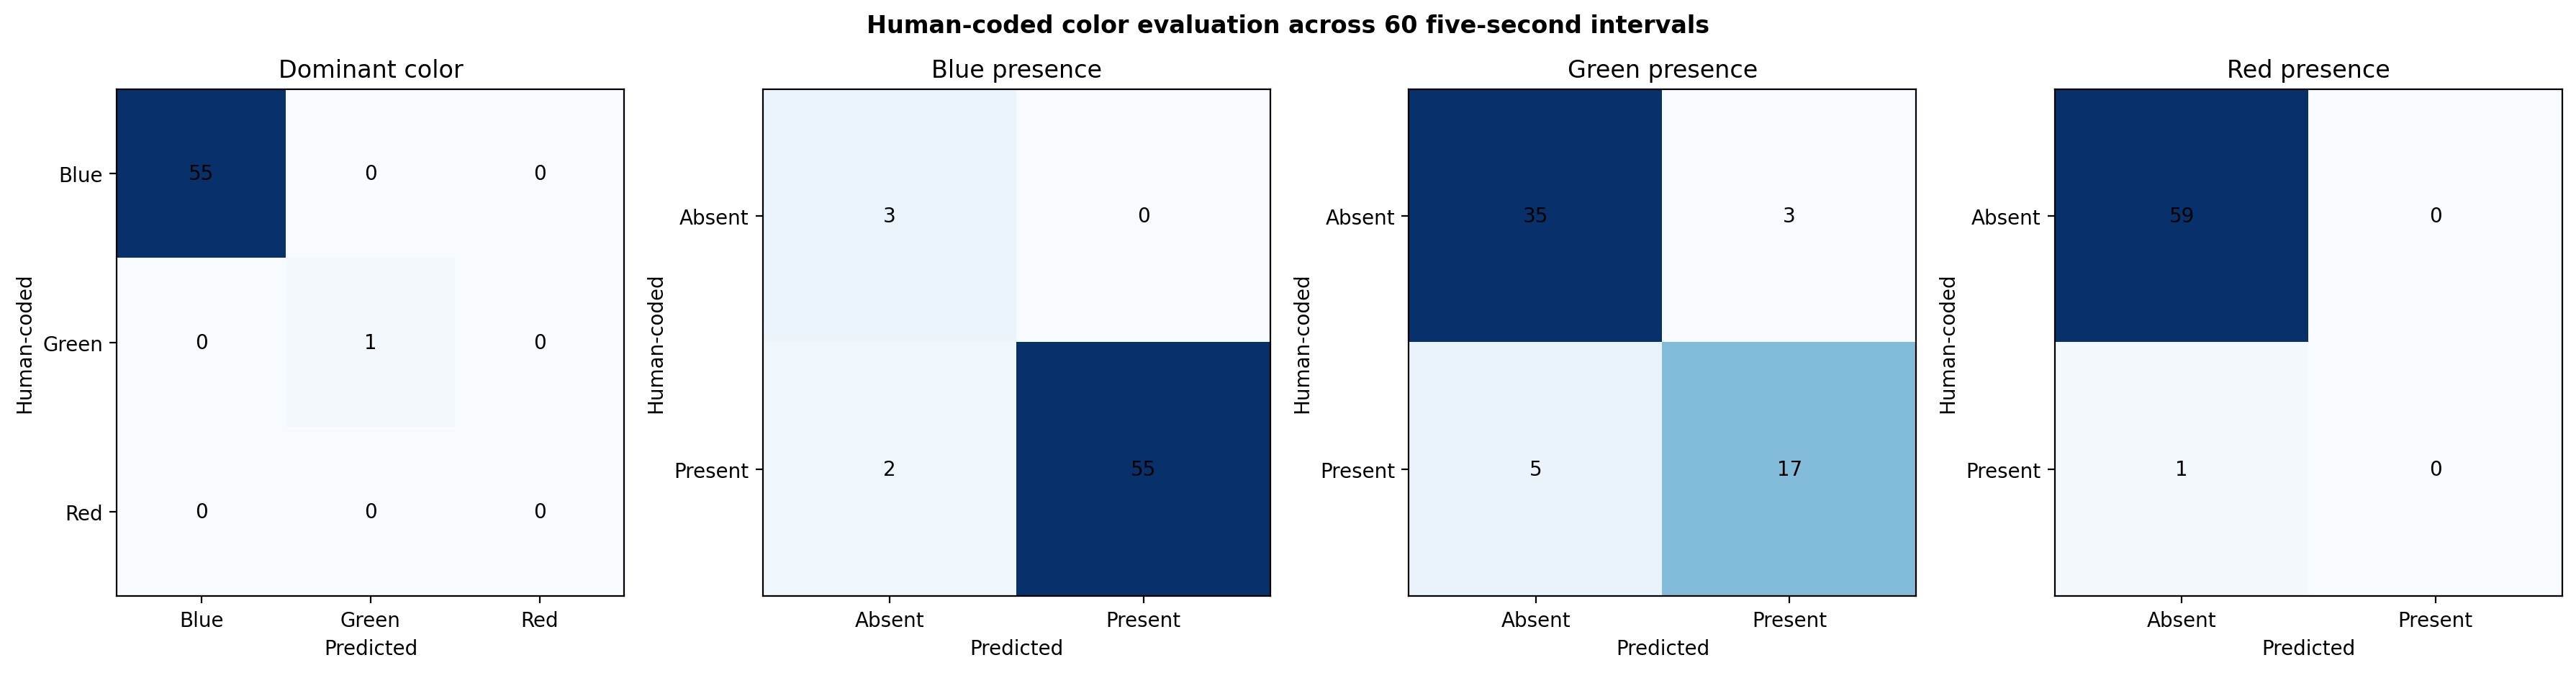

In [13]:
human_all_colors = pd.read_csv(HUMAN_GEMS_CSV)
color_eval = human_all_colors.merge(
    five_second_model[[
        "time_stamp", "likely_collected_blue_gems",
        "likely_collected_green_gems", "likely_collected_red_gems",
    ]],
    on="time_stamp", how="inner", validate="one_to_one",
)
colors = np.asarray(helpers.COLORS)
actual_columns = [f"actual_collected_{color}_gems" for color in helpers.COLORS]
predicted_columns = [f"likely_collected_{color}_gems" for color in helpers.COLORS]
actual_total = color_eval[actual_columns].sum(axis=1)
predicted_total = color_eval[predicted_columns].sum(axis=1)
dominant_usable = actual_total.gt(0) & predicted_total.gt(0)
color_eval["actual_dominant_color"] = "none"
color_eval["predicted_dominant_color"] = "none"
color_eval.loc[actual_total.gt(0), "actual_dominant_color"] = colors[
    color_eval.loc[actual_total.gt(0), actual_columns].to_numpy().argmax(axis=1)
]
color_eval.loc[predicted_total.gt(0), "predicted_dominant_color"] = colors[
    color_eval.loc[predicted_total.gt(0), predicted_columns].to_numpy().argmax(axis=1)
]

dominant_color_matrix = confusion_matrix(
    color_eval.loc[dominant_usable, "actual_dominant_color"],
    color_eval.loc[dominant_usable, "predicted_dominant_color"],
    labels=helpers.COLORS,
)
dominant_color_table = pd.DataFrame(
    dominant_color_matrix,
    index=[f"Actual {color.title()}" for color in helpers.COLORS],
    columns=[f"Predicted {color.title()}" for color in helpers.COLORS],
)
dominant_accuracy = float(
    np.mean(
        color_eval.loc[dominant_usable, "actual_dominant_color"]
        == color_eval.loc[dominant_usable, "predicted_dominant_color"]
    )
)
display(dominant_color_table)
print(
    f"Dominant-color accuracy: {dominant_accuracy:.2%} over "
    f"{int(dominant_usable.sum())} evaluable intervals; "
    f"{int((~dominant_usable).sum())} zero-total intervals excluded."
)

presence_rows = []
presence_matrices = {}
for color in helpers.COLORS:
    actual_present = color_eval[f"actual_collected_{color}_gems"].gt(0)
    predicted_present = color_eval[f"likely_collected_{color}_gems"].gt(0)
    matrix = confusion_matrix(actual_present, predicted_present, labels=[False, True])
    presence_matrices[color] = matrix
    tn, fp, fn, tp = matrix.ravel()
    presence_rows.append({
        "Color": color.title(), "TN": int(tn), "FP": int(fp),
        "FN": int(fn), "TP": int(tp),
        "Presence accuracy": float((tn + tp) / matrix.sum()),
        "Presence precision": float(tp / (tp + fp)) if tp + fp else np.nan,
        "Presence recall": float(tp / (tp + fn)) if tp + fn else np.nan,
    })
presence_metrics = pd.DataFrame(presence_rows)
display(presence_metrics.style.format({
    "Presence accuracy": "{:.2%}",
    "Presence precision": "{:.2%}",
    "Presence recall": "{:.2%}",
}))

fig, axes = plt.subplots(1, 4, figsize=(18, 4.6))
panels = [("Dominant color", dominant_color_matrix, helpers.COLORS, helpers.COLORS)]
panels.extend(
    (f"{color.title()} presence", presence_matrices[color], ["Absent", "Present"], ["Absent", "Present"])
    for color in helpers.COLORS
)
for ax, (title, matrix, xlabels, ylabels) in zip(axes, panels):
    ax.imshow(matrix, cmap="Blues")
    for row in range(matrix.shape[0]):
        for column in range(matrix.shape[1]):
            ax.text(column, row, int(matrix[row, column]), ha="center", va="center")
    ax.set(
        title=title, xticks=range(len(xlabels)),
        xticklabels=[str(value).title() for value in xlabels],
        yticks=range(len(ylabels)),
        yticklabels=[str(value).title() for value in ylabels],
        xlabel="Predicted", ylabel="Human-coded",
    )
fig.suptitle("Human-coded color evaluation across 60 five-second intervals", fontweight="bold")
fig.tight_layout()
COLOR_CONFUSION_PNG = OUTPUT / "xp_weak_visual_human_color_confusions.png"
COLOR_CONFUSION_JPG = OUTPUT / "xp_weak_visual_human_color_confusions.jpg"
fig.savefig(COLOR_CONFUSION_PNG, dpi=200, bbox_inches="tight")
fig.savefig(COLOR_CONFUSION_JPG, dpi=200, bbox_inches="tight", pil_kwargs={"quality": 94})
plt.close(fig)

color_eval.to_csv(OUTPUT / "xp_weak_visual_human_color_evaluation.csv", index=False)
dominant_color_table.to_csv(OUTPUT / "xp_weak_visual_human_dominant_color_confusion.csv")
presence_metrics.to_csv(OUTPUT / "xp_weak_visual_human_color_presence_metrics.csv", index=False)
display(NotebookImage(filename=str(COLOR_CONFUSION_JPG), width=1450))

assert len(color_eval) == 60

## Primary evaluation: three-color count estimation

The scientifically appropriate target is the vector of blue, green, and red counts in each
five-second interval. Per-color errors show which colors are under- or over-counted. Macro
metrics give every color equal importance; weighted metrics reflect the observed number of
gems. Color-composition error measures the total absolute color-count error relative to the
human-coded number of gems in an interval.

For this task, per-color MAE, bias, recall/presence, and total-count error are more actionable
than RMSE alone. RMSE remains useful because it penalizes occasional large interval errors,
but it can hide whether errors are systematic undercounting, color substitution, or a few
extreme intervals.

,Color,Intervals,Human total,Predicted total,Total error,Bias,MAE,RMSE,Exact-count accuracy,Within-one accuracy,Correlation
0,Blue,60,704,647,-57,-0.950,2.950,4.493,20.00%,46.67%,0.908
1,Green,60,47,35,-12,-0.200,0.400,0.856,73.33%,90.00%,0.763
2,Red,60,1,0,-1,-0.017,0.017,0.129,98.33%,100.00%,nan


,Metric,Value
0,Macro MAE,1.1222
1,Macro RMSE,1.8260
2,Weighted MAE per human gem,0.2686
3,Pooled RMSE across 180 color-interval cells,2.6415
4,Mean interval color-composition error,0.3366
5,Median interval color-composition error,0.2500
6,Human total gems,752.0000
7,Predicted total gems,682.0000
8,Total gem-count error,-70.0000


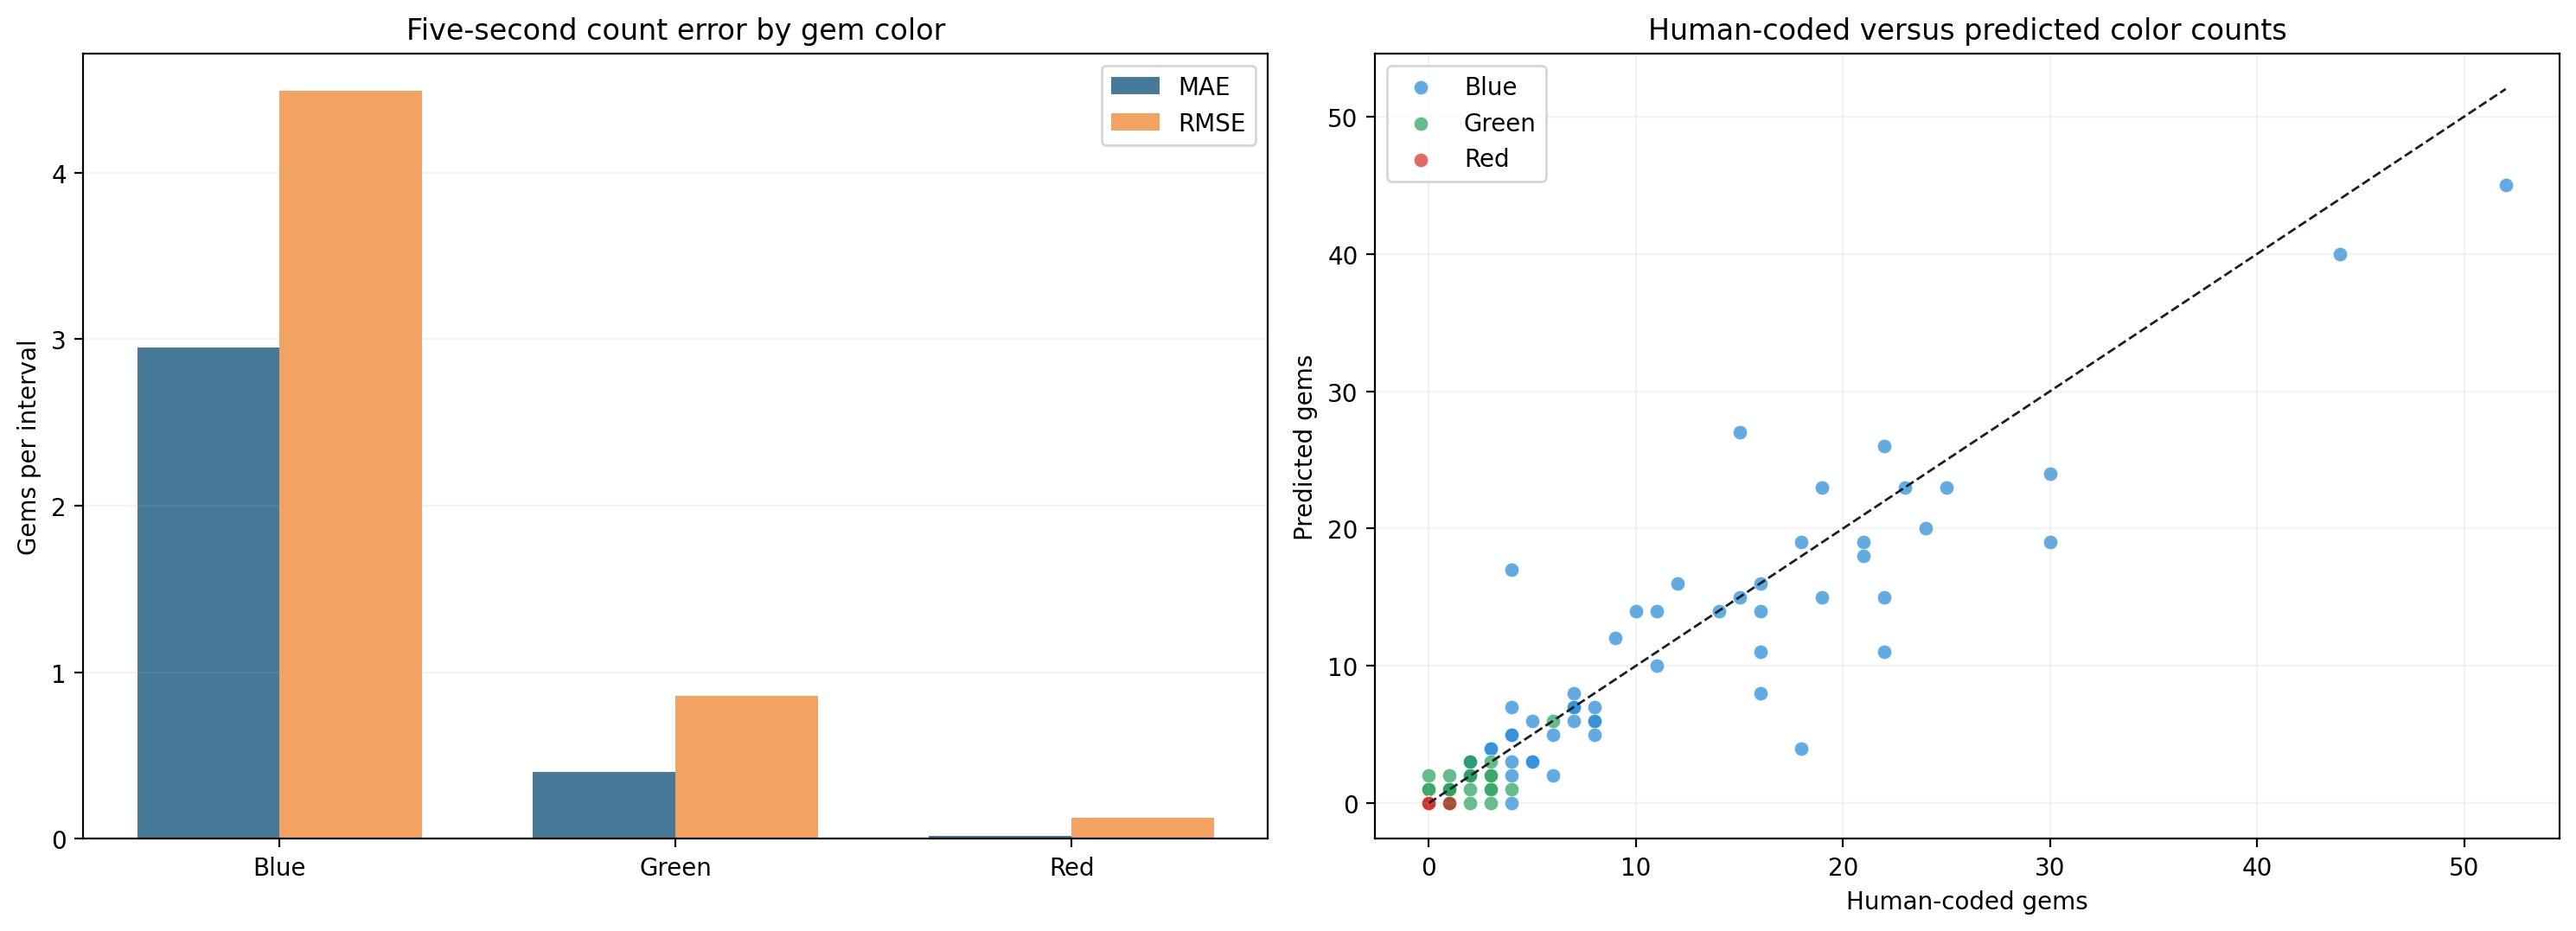

In [14]:
count_metric_rows = []
all_absolute_errors = []
all_squared_errors = []
all_actual_counts = []
for color in helpers.COLORS:
    actual = color_eval[f"actual_collected_{color}_gems"].astype(float)
    predicted = color_eval[f"likely_collected_{color}_gems"].astype(float)
    error = predicted - actual
    count_metric_rows.append({
        "Color": color.title(),
        "Intervals": len(actual),
        "Human total": int(actual.sum()),
        "Predicted total": int(predicted.sum()),
        "Total error": int(error.sum()),
        "Bias": float(error.mean()),
        "MAE": float(np.abs(error).mean()),
        "RMSE": float(np.sqrt(np.square(error).mean())),
        "Exact-count accuracy": float(error.eq(0).mean()),
        "Within-one accuracy": float(error.abs().le(1).mean()),
        "Correlation": float(actual.corr(predicted)) if actual.nunique() > 1 and predicted.nunique() > 1 else np.nan,
    })
    all_absolute_errors.append(np.abs(error).to_numpy())
    all_squared_errors.append(np.square(error).to_numpy())
    all_actual_counts.append(actual.to_numpy())

three_color_count_metrics = pd.DataFrame(count_metric_rows)
macro_mae = float(three_color_count_metrics["MAE"].mean())
macro_rmse = float(three_color_count_metrics["RMSE"].mean())
absolute_error_array = np.vstack(all_absolute_errors)
squared_error_array = np.vstack(all_squared_errors)
actual_count_array = np.vstack(all_actual_counts)
weighted_mae = float(absolute_error_array.sum() / actual_count_array.sum())
pooled_rmse = float(np.sqrt(squared_error_array.mean()))

actual_color_total = color_eval[actual_columns].sum(axis=1).astype(float)
predicted_color_total = color_eval[predicted_columns].sum(axis=1).astype(float)
interval_absolute_color_error = np.zeros(len(color_eval), dtype=float)
for color in helpers.COLORS:
    interval_absolute_color_error += np.abs(
        color_eval[f"likely_collected_{color}_gems"]
        - color_eval[f"actual_collected_{color}_gems"]
    )
color_eval["absolute_color_count_error"] = interval_absolute_color_error
color_eval["color_composition_error"] = np.where(
    actual_color_total.gt(0),
    interval_absolute_color_error / actual_color_total,
    np.where(predicted_color_total.eq(0), 0.0, np.nan),
)

overall_count_metrics = pd.DataFrame([
    {"Metric": "Macro MAE", "Value": macro_mae},
    {"Metric": "Macro RMSE", "Value": macro_rmse},
    {"Metric": "Weighted MAE per human gem", "Value": weighted_mae},
    {"Metric": "Pooled RMSE across 180 color-interval cells", "Value": pooled_rmse},
    {"Metric": "Mean interval color-composition error", "Value": float(np.nanmean(color_eval["color_composition_error"]))},
    {"Metric": "Median interval color-composition error", "Value": float(np.nanmedian(color_eval["color_composition_error"]))},
    {"Metric": "Human total gems", "Value": int(actual_color_total.sum())},
    {"Metric": "Predicted total gems", "Value": int(predicted_color_total.sum())},
    {"Metric": "Total gem-count error", "Value": int(predicted_color_total.sum() - actual_color_total.sum())},
])

display(three_color_count_metrics.style.format({
    "Bias": "{:+.3f}", "MAE": "{:.3f}", "RMSE": "{:.3f}",
    "Exact-count accuracy": "{:.2%}", "Within-one accuracy": "{:.2%}",
    "Correlation": "{:.3f}",
}))
display(overall_count_metrics.style.format({"Value": "{:.4f}"}))

fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
x = np.arange(len(helpers.COLORS))
width = 0.36
axes[0].bar(
    x - width / 2, three_color_count_metrics["MAE"], width,
    label="MAE", color="#477998",
)
axes[0].bar(
    x + width / 2, three_color_count_metrics["RMSE"], width,
    label="RMSE", color="#f4a261",
)
axes[0].set(
    title="Five-second count error by gem color",
    xticks=x, xticklabels=[color.title() for color in helpers.COLORS],
    ylabel="Gems per interval",
)
axes[0].legend()
axes[0].grid(axis="y", alpha=0.15)

for color in helpers.COLORS:
    axes[1].scatter(
        color_eval[f"actual_collected_{color}_gems"],
        color_eval[f"likely_collected_{color}_gems"],
        color=helpers.DISPLAY_COLORS[color], alpha=0.72, s=35,
        label=color.title(), edgecolors="white", linewidths=0.3,
    )
maximum_count = max(
    color_eval[actual_columns].to_numpy().max(),
    color_eval[predicted_columns].to_numpy().max(),
)
axes[1].plot([0, maximum_count], [0, maximum_count], "--", color="#18212b", linewidth=1)
axes[1].set(
    title="Human-coded versus predicted color counts",
    xlabel="Human-coded gems", ylabel="Predicted gems",
)
axes[1].legend()
axes[1].grid(alpha=0.15)
fig.tight_layout()
COUNT_METRICS_PNG = OUTPUT / "xp_weak_visual_three_color_count_metrics.png"
COUNT_METRICS_JPG = OUTPUT / "xp_weak_visual_three_color_count_metrics.jpg"
fig.savefig(COUNT_METRICS_PNG, dpi=200, bbox_inches="tight")
fig.savefig(COUNT_METRICS_JPG, dpi=200, bbox_inches="tight", pil_kwargs={"quality": 94})
plt.close(fig)

three_color_count_metrics.to_csv(
    OUTPUT / "xp_weak_visual_three_color_count_metrics.csv", index=False
)
overall_count_metrics.to_csv(
    OUTPUT / "xp_weak_visual_three_color_overall_metrics.csv", index=False
)
color_eval.to_csv(OUTPUT / "xp_weak_visual_human_color_evaluation.csv", index=False)
display(NotebookImage(filename=str(COUNT_METRICS_JPG), width=1250))

## Detailed review: 3:14-3:15

This second contains two adjacent XP jumps. Event 331 was previously resolved blue. Event
332 remained unresolved because normalized XP suggested green while the sensitive pass found
`blue | blue | green`. The weak visual model predicts event 332 from the complete learned
feature pattern, but the adjacent-event ambiguity still makes it an important audit example.

,event_id,frame_a,frame_b,video_time_stamp,hud_level,xp_bar_increase_percent,level_normalized_xp_gain,count_trajectory_colors,count_trajectory_track_count,model_prediction,model_confidence,probability_blue,probability_green,probability_red,model_status
331,332,5834,5835,3:14.500,11,3.9672,2.9306,blue|blue|green,3,green,0.609,0.391,0.609,0.0,low_confidence_review


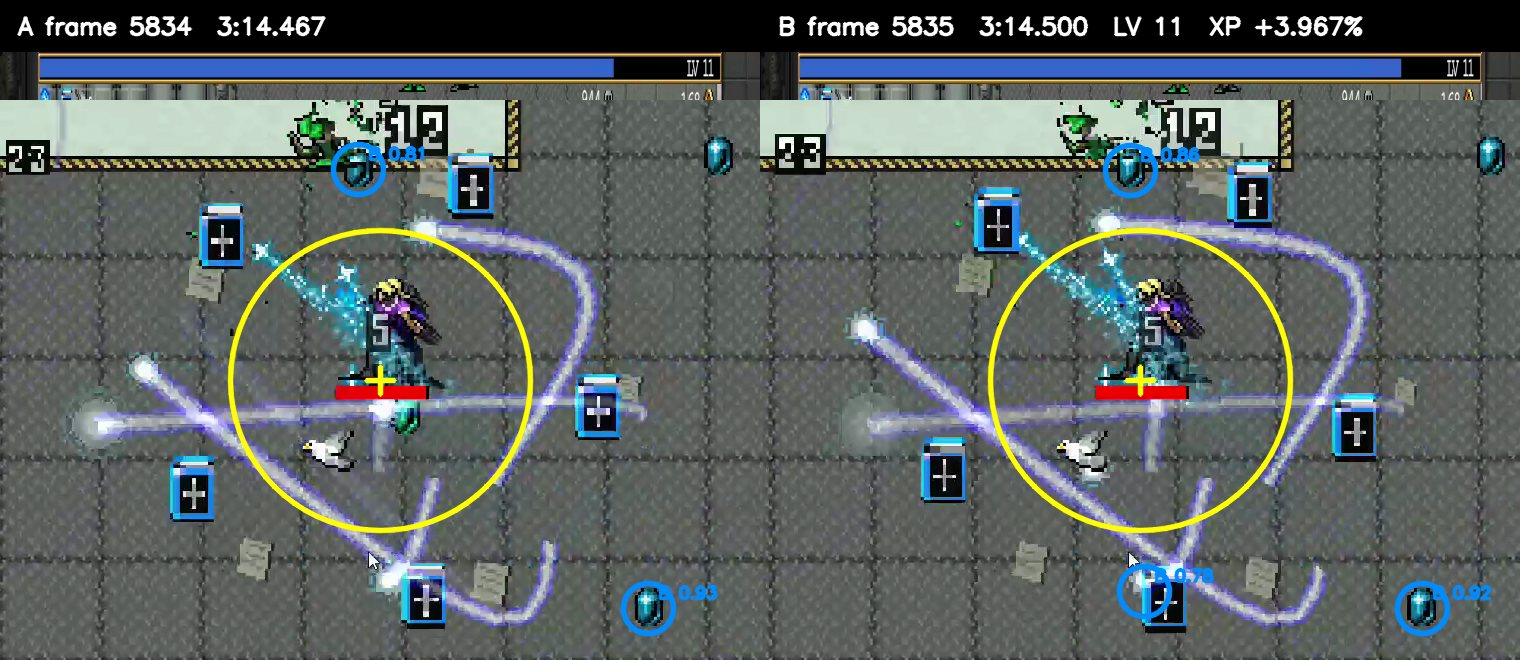

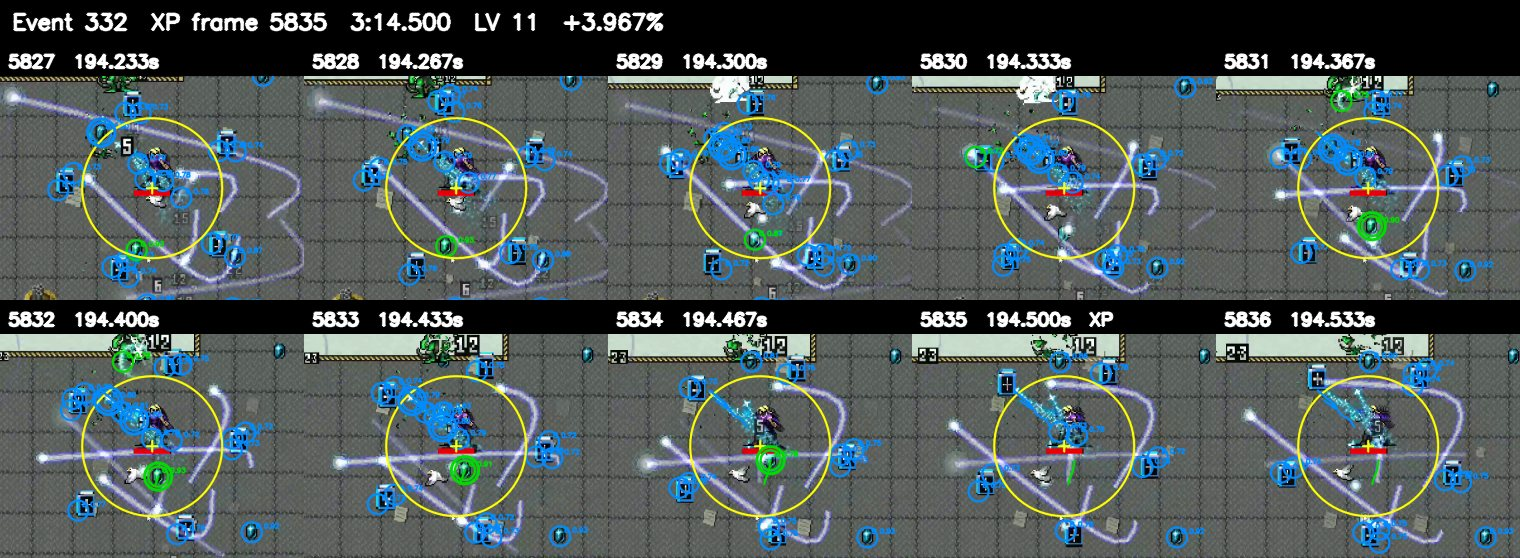

In [15]:
review_interval = unresolved_predictions.loc[
    unresolved_predictions["event_id"].eq(332),
    [
        "event_id", "frame_a", "frame_b", "video_time_stamp", "hud_level",
        "xp_bar_increase_percent", "level_normalized_xp_gain",
        "count_trajectory_colors", "count_trajectory_track_count",
        "model_prediction", "model_confidence",
        "probability_blue", "probability_green", "probability_red", "model_status",
    ],
]
display(review_interval)

PAIR_IMAGE = (
    PROJECT / "results" / "video4_Imelda_100" / "collected_gems_cv_final"
    / "ab_pairs" / "event_00332_frames_5834_5835.jpg"
)
TRAJECTORY_IMAGE = (
    PROJECT / "results" / "video4_Imelda_100" / "collected_gems_cv_final"
    / "event_reviews" / "3_14_to_3_15"
    / "event_00332_sensitive_trajectory_frames_5827_5836.jpg"
)
assert PAIR_IMAGE.exists() and TRAJECTORY_IMAGE.exists()
display(NotebookImage(filename=str(PAIR_IMAGE), width=1250))
display(NotebookImage(filename=str(TRAJECTORY_IMAGE), width=1250))

## Limitations, removal decisions, and next steps

- Training and cross-validation use computer-vision labels, not independent human ground truth.
- The independent Gaming Content comparison covers blue counts for only the first five minutes.
- Blue and green have useful reference support; red has only three reference events.
- Simultaneous pickups can share one XP jump and imitate another gem's XP value.
- Adjacent XP events can compete for the same trajectory evidence.
- Saturated jumps do not reveal gem value because level-up XP has no overflow; only the
  strict single-track visual rule may color them.
- Random-forest confidence is a model score, not a guaranteed real-world probability.
- The Crown schedule is audited for this specific Video 4 run; another video requires its own
  Growth/Crown timeline or an automated inventory/stat-panel reader.
- The +15% starting Growth PowerUp is specific to this recorded setup.

Use the model as the broad candidate assignment and review all red, level-up visual,
remaining saturated, low-confidence, and adjacent-event cases. A future independent
human-labeled test set should be evaluated before replacing the production detector's
conservative colors.

### Keep

- XP jumps as pickup confirmation;
- multi-frame trajectory and occlusion handling;
- Crown-aware level normalization;
- out-of-fold internal validation;
- independent five-second human evaluation; and
- separate production, candidate, and likely-color fields.

### Do not use as primary evidence

- raw on-screen gem counts, because many visible gems are never collected;
- pickup sound alone, because it does not identify color or multiplicity;
- XP magnitude without Growth correction;
- single-frame disappearance without trajectory context; or
- dominant-color accuracy by itself, because blue-heavy intervals make it misleading.

### Highest-value additions

1. Complete independent human coding at the XP-event level, including blue, green, red,
   unknown, and simultaneous-pickup quantity.
2. Calibrate confidence using held-out human labels and report reliability curves.
3. Add automated Crown/stat-panel OCR with visual audit frames instead of a video-specific
   schedule.
4. Evaluate temporal blocks separately so neighboring frames cannot make train and validation
   folds overly similar.
5. Report bootstrap confidence intervals, especially for green and red performance.

In [16]:
summary = {
    "model": "XP and Trajectory Gem Classification Model",
    "reference_events": len(reference),
    "reference_blue": int((truth == "blue").sum()),
    "reference_green": int((truth == "green").sum()),
    "reference_red": int((truth == "red").sum()),
    "out_of_fold_accuracy": round(float(accuracy), 6),
    "out_of_fold_balanced_accuracy": round(float(balanced_accuracy), 6),
    "out_of_fold_macro_f1": round(float(macro_f1), 6),
    "unresolved_input_events": len(unresolved),
    "candidate_blue": outcome_counts["blue"],
    "candidate_green": outcome_counts["green"],
    "candidate_red": outcome_counts["red"],
    "still_unresolved": outcome_counts["unresolved"],
    "unresolved_with_likely_color": int(
        unresolved_predictions.loc[still_saturated, "likely_color"].ne("").sum()
    ),
    "human_exact_count_accuracy": round(float(
        human_metrics.loc[human_metrics["Estimate"].eq("Including likely colors"), "Exact-count accuracy"].iloc[0]
    ), 6),
    "human_within_one_accuracy": round(float(
        human_metrics.loc[human_metrics["Estimate"].eq("Including likely colors"), "Within-one accuracy"].iloc[0]
    ), 6),
    "human_mae": round(float(
        human_metrics.loc[human_metrics["Estimate"].eq("Including likely colors"), "MAE"].iloc[0]
    ), 6),
    "human_rmse": round(float(
        human_metrics.loc[human_metrics["Estimate"].eq("Including likely colors"), "RMSE"].iloc[0]
    ), 6),
    "human_three_color_macro_mae": round(macro_mae, 6),
    "human_three_color_macro_rmse": round(macro_rmse, 6),
    "human_three_color_weighted_mae": round(weighted_mae, 6),
    "human_mean_color_composition_error": round(float(
        np.nanmean(color_eval["color_composition_error"])
    ), 6),
    "official_detector_outputs_modified": False,
    "human_coded_sheet_used_for_training": False,
    "human_coded_sheet_used_for_evaluation": True,
}
(OUTPUT / "xp_weak_visual_model_summary.json").write_text(
    json.dumps(summary, indent=2) + "\n"
)
pd.DataFrame([summary]).to_csv(OUTPUT / "xp_weak_visual_model_summary.csv", index=False)

assert 0.0 <= accuracy <= 1.0
assert int((truth == oof_prediction).sum()) == int(validation_predictions["correct"].sum())
assert sum(int((model_prediction == color).sum()) for color in helpers.COLORS) + int(
    (model_prediction == "").sum()
) == len(unresolved)
assert outcome_counts["red"] >= 0
assert outcome_counts["unresolved"] == int(still_saturated.sum())
assert summary["official_detector_outputs_modified"] is False
assert summary["human_coded_sheet_used_for_training"] is False
assert summary["human_coded_sheet_used_for_evaluation"] is True

display(pd.DataFrame([summary]).T.rename(columns={0: "Value"}))
print("All XP and Trajectory Gem Classification Model validation checks passed.")

,Value
model,XP and Trajectory Gem Classification Model
reference_events,1254
reference_blue,971
reference_green,280
reference_red,3
out_of_fold_accuracy,0.9689
out_of_fold_balanced_accuracy,0.866525
out_of_fold_macro_f1,0.860693
unresolved_input_events,849
candidate_blue,640


All XP and Trajectory Gem Classification Model validation checks passed.
